# Dataset Analysis for Numericals Datasets

## Libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
%store -r data
data=data

%store -r numerical_cols
numerical_cols=numerical_cols



##  Descriptive Analysis

#### Numerical Data

In [3]:
numerical_cols= data.select_dtypes(include=['int64','float64' ]).columns.tolist()
print(data[numerical_cols].columns)
print(data[numerical_cols])

Index(['year_of_manufacture', 'Engine_power(kilowatt)',
       'Engine_power_(Horsepower)', 'Mileage', 'Nber_previous_owners',
       'damaged_front', 'damaged_rear', 'damaged_left_side',
       'damaged_exterior', 'damaged_tire', 'damaged_interior', 'damaged_rim',
       'damaged_roof_beam', 'damaged_left_door', 'damaged_right_door',
       'damaged_seats', 'interior_dirty', 'damaged_carosserie', 'days_to_TUV',
       'Sale price'],
      dtype='object')
      year_of_manufacture  Engine_power(kilowatt)  Engine_power_(Horsepower)  \
0                    2023                      96                        130   
1                    2022                     113                        153   
2                    2023                     139                        188   
3                    2021                      99                        134   
4                    2020                      67                         91   
...                   ...                     ...           

In [4]:
def kde_plot(x):
    col = x[0]

    plt.figure(figsize=(12,6))

    # Histogramm
    sns.histplot(data[x[0]], kde=False, alpha=0.25)

    # KDE-Plot
    sns.kdeplot(data[x[0]], linewidth=5)
    
    # Calculate mean and median
    mean=data[col].mean()
    median=data[col].median()
    
    # Add mean and median lines
    plt.axvline(mean, color='r', linestyle='--', label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='-', label=f'Median: {median:.2f}')
    
    # Add legend and labels
    plt.legend()
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(x)
    plt.ylabel('Density')

    return plt.show()



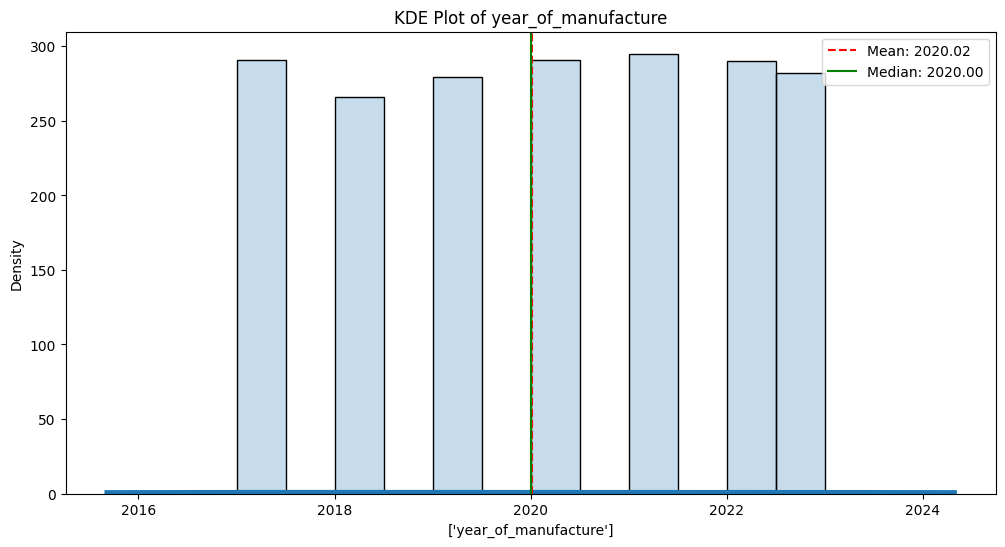

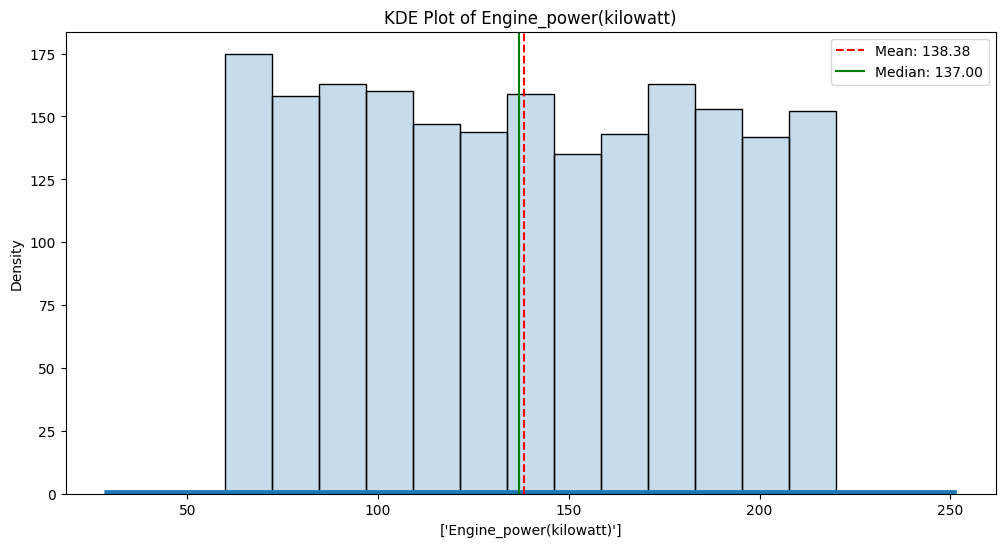

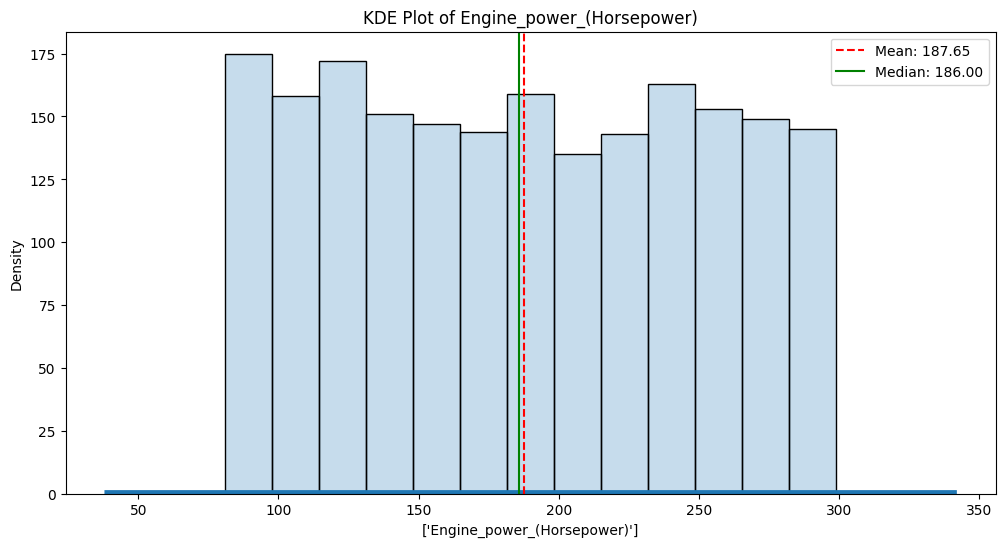

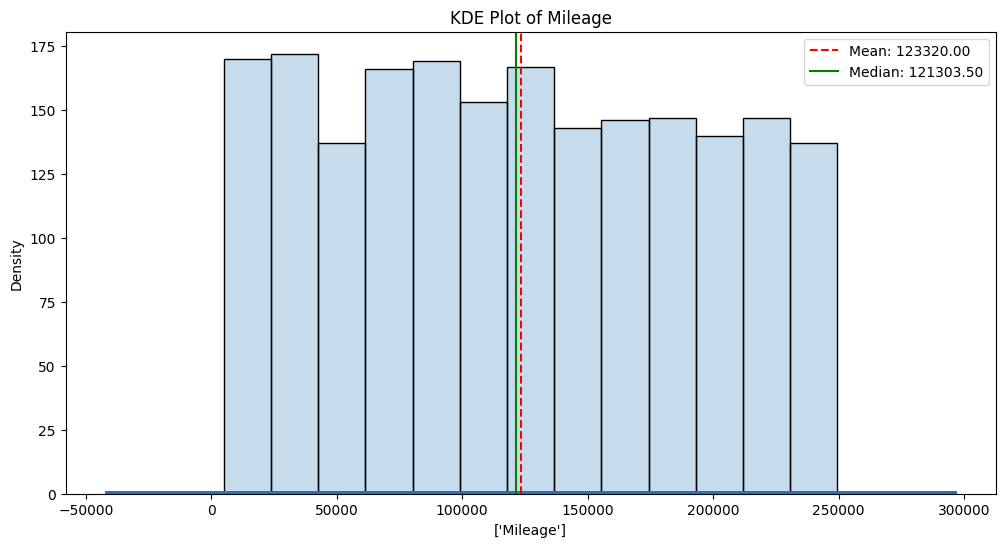

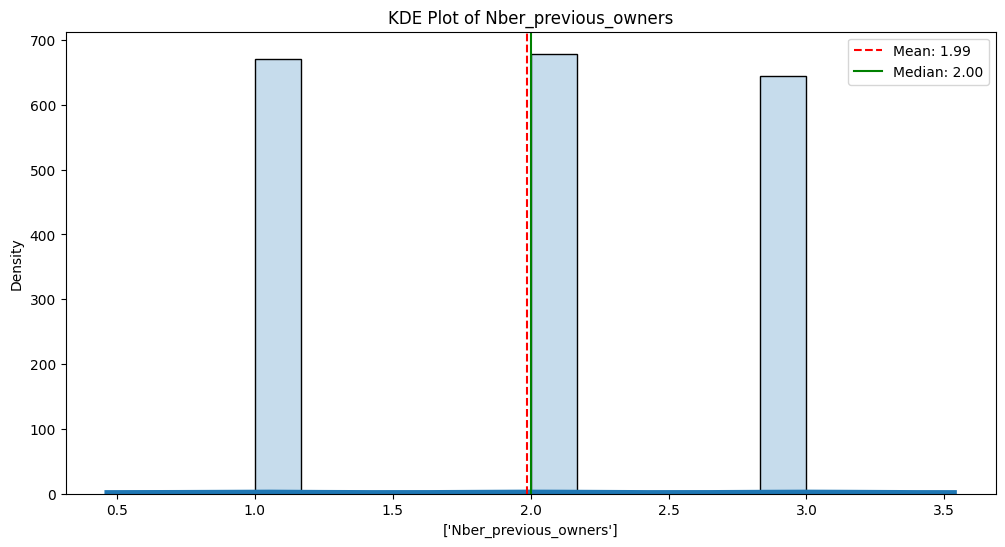

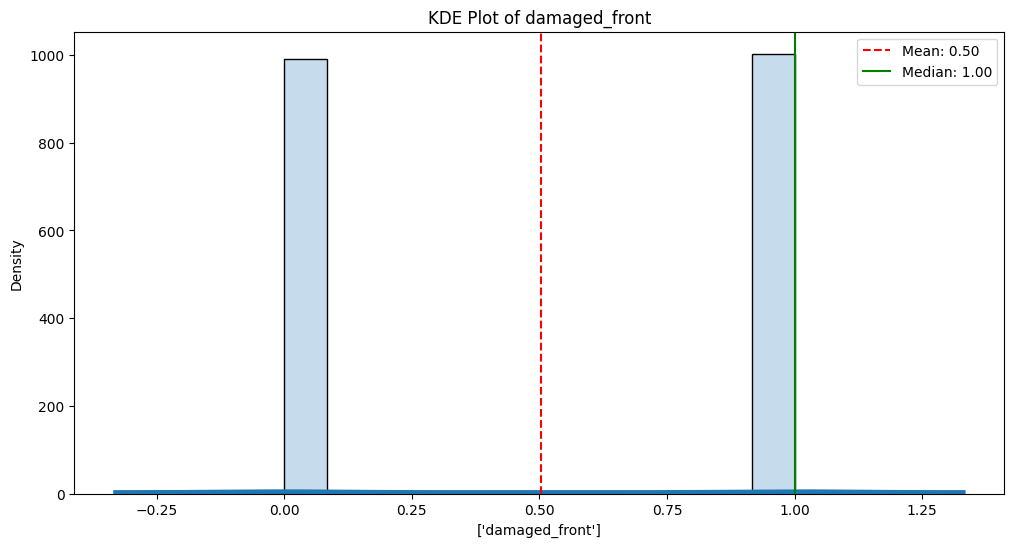

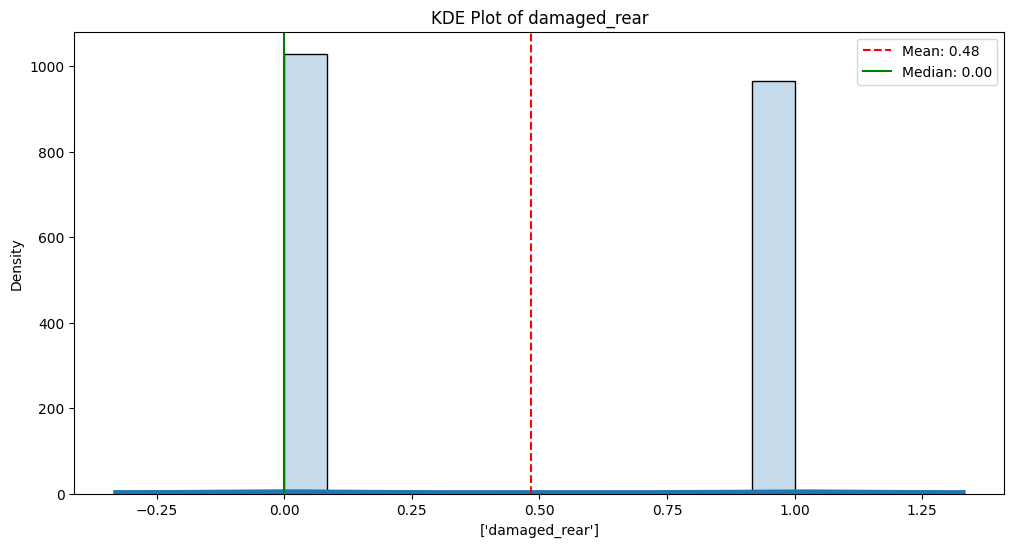

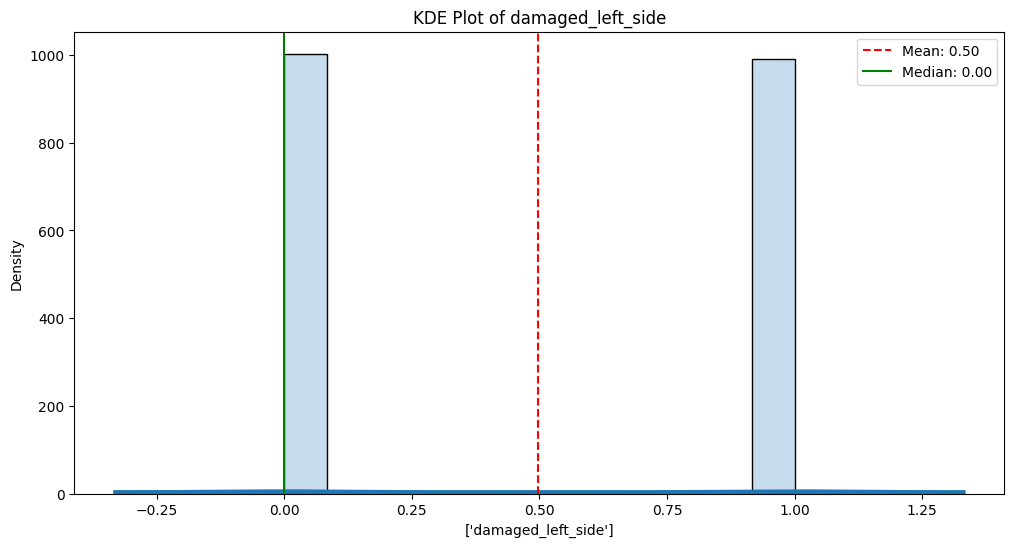

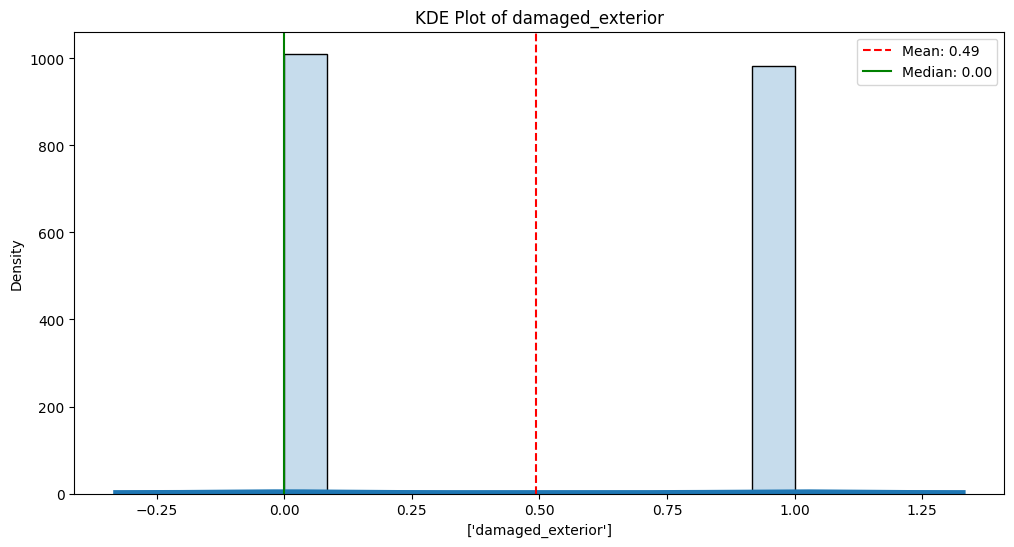

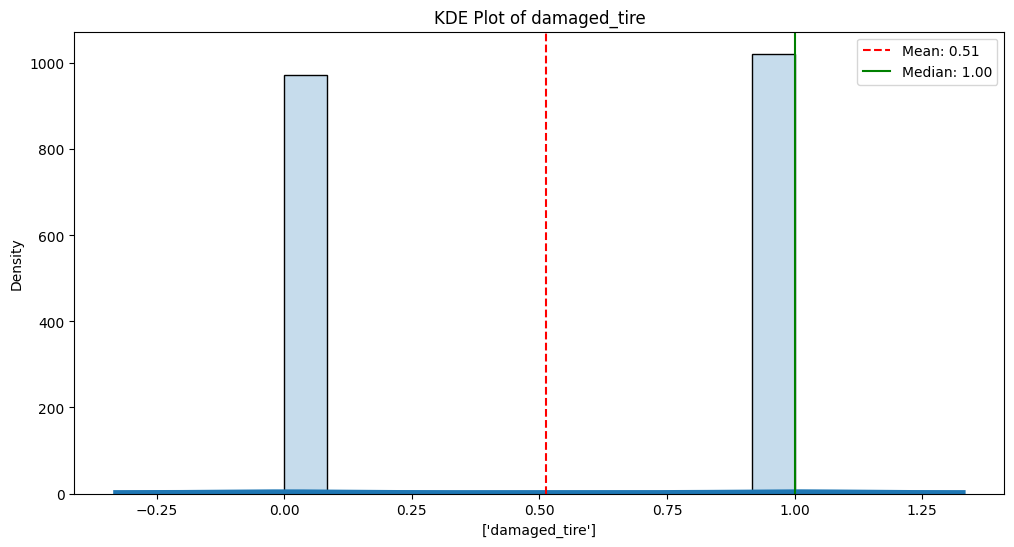

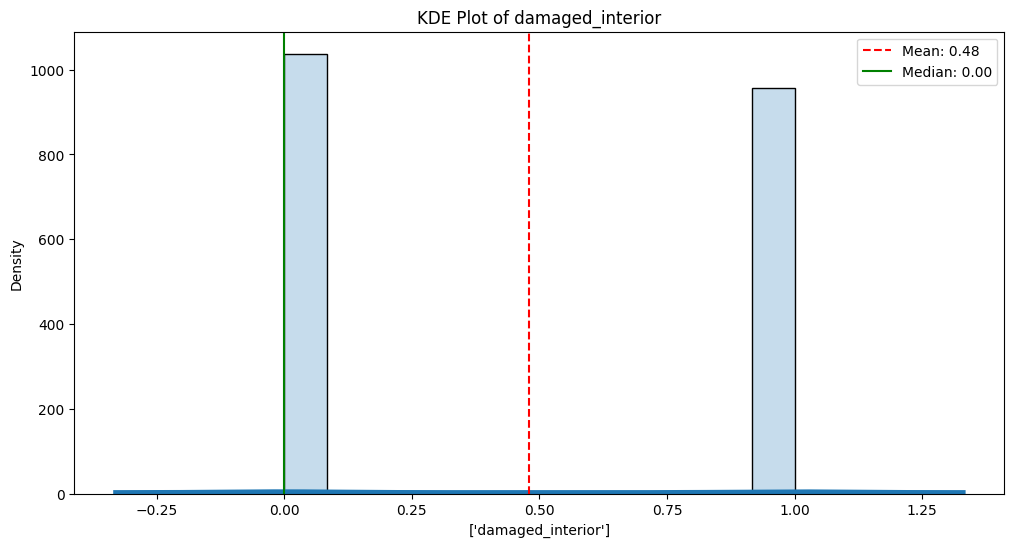

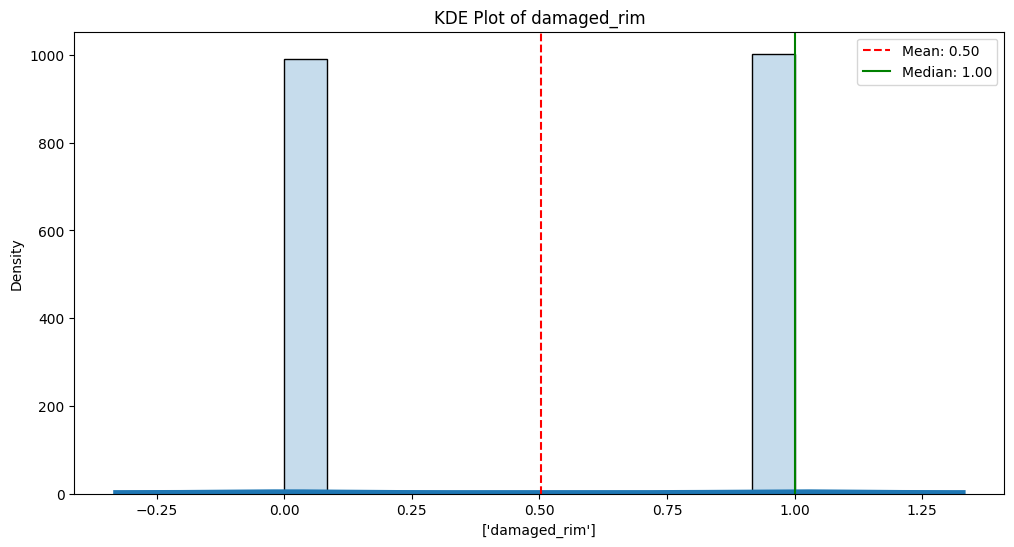

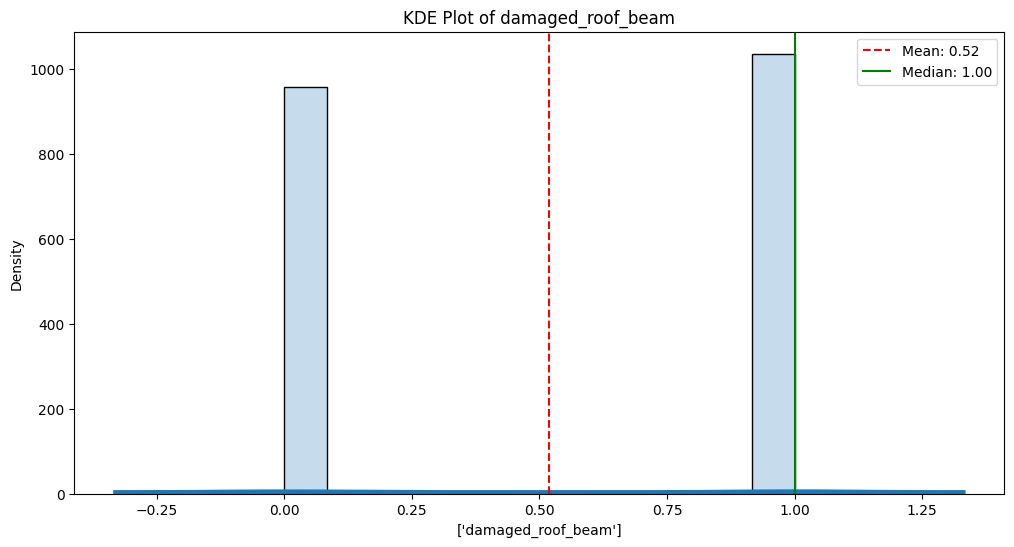

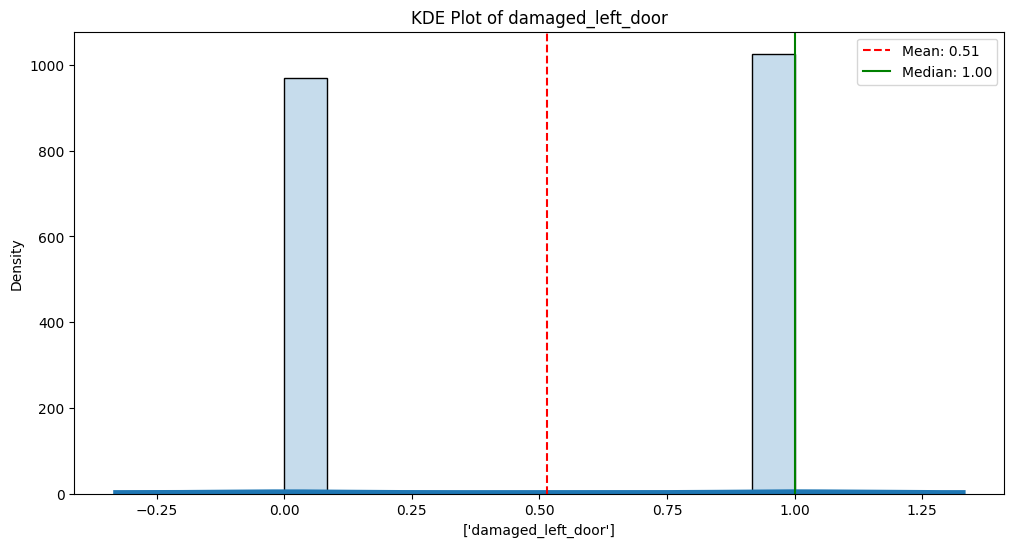

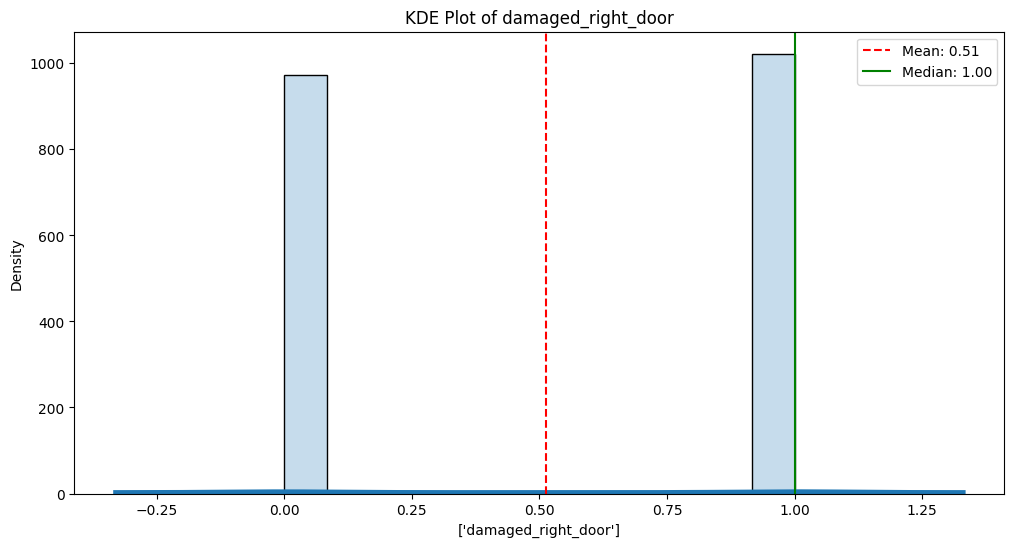

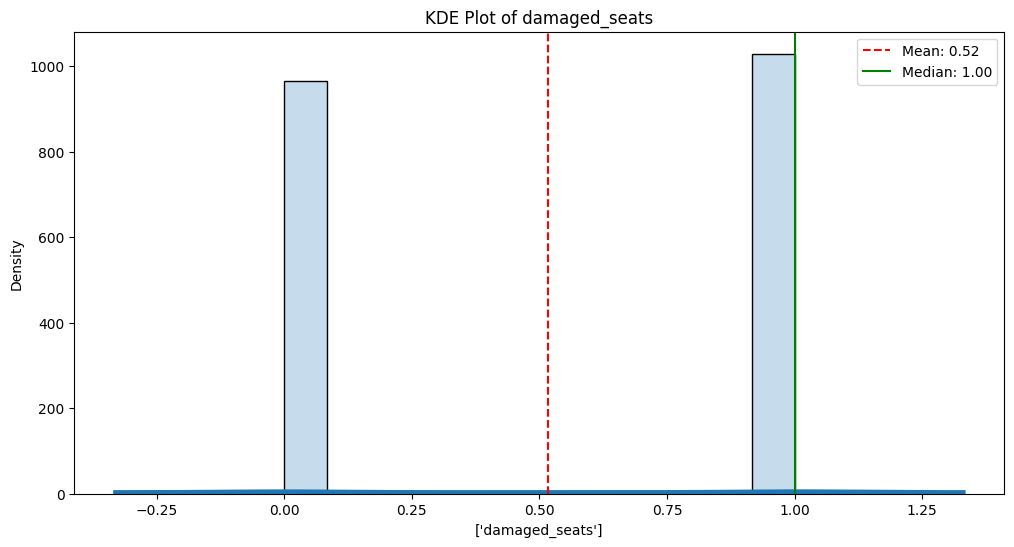

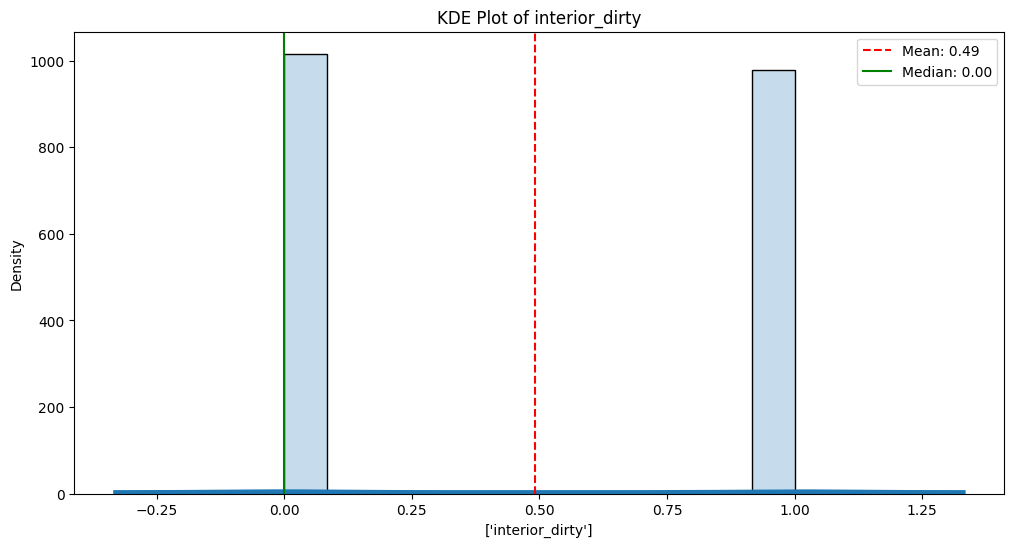

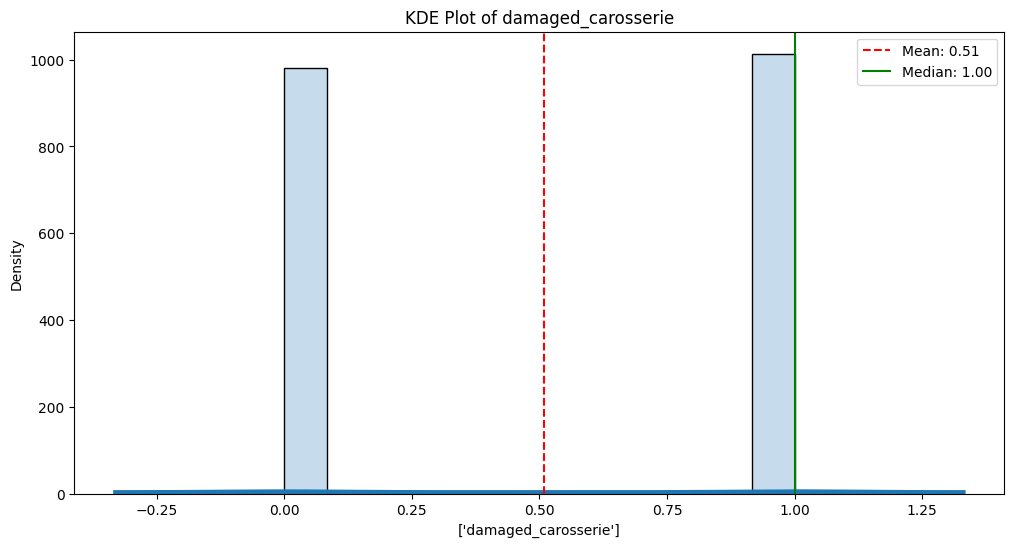

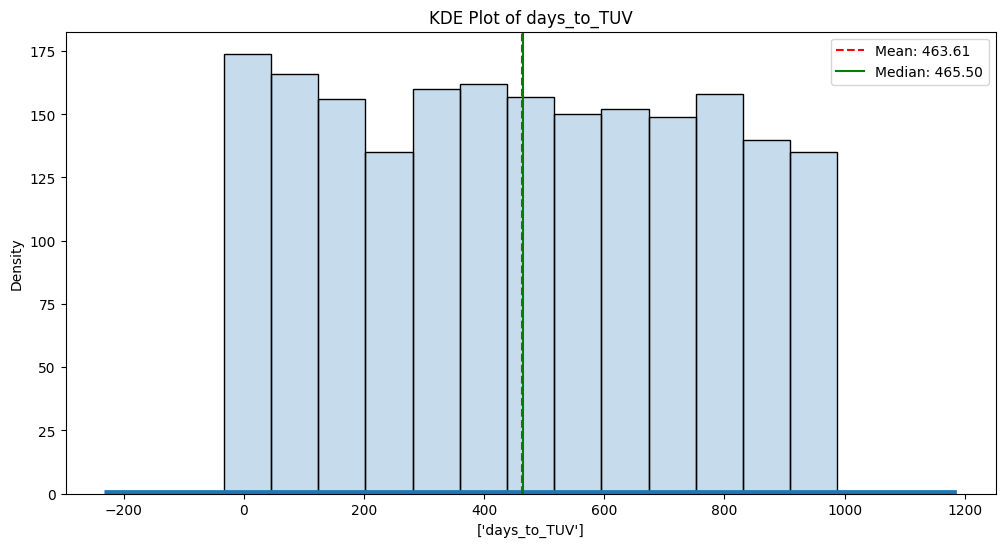

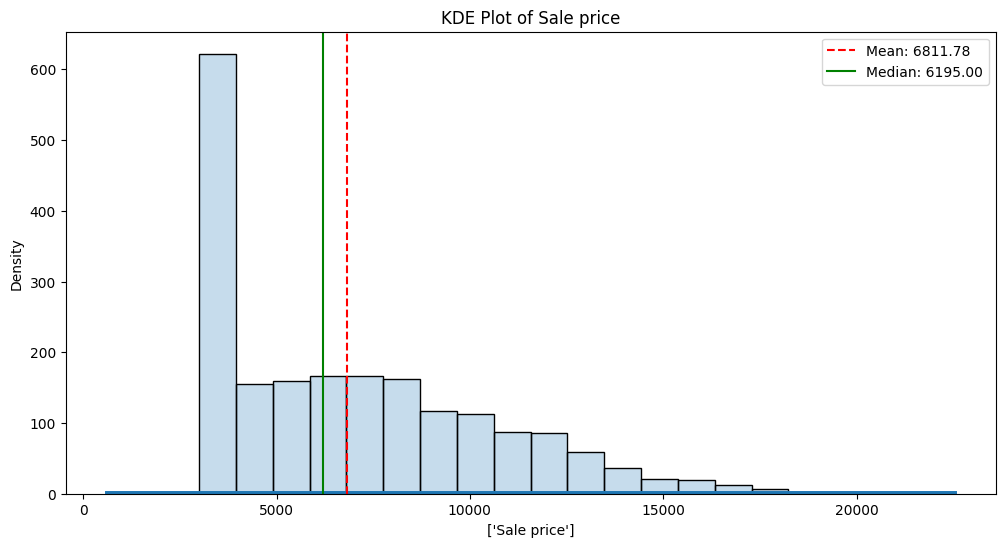

In [5]:
# Generate KDE plots for all numerical columns
for col in numerical_cols:
    kde_plot([col])

    print('\n\n')

#### Scatter Plot

In [6]:
def scatter_plot(x):
    col=x[0]

    plt.figure(figsize=(12,6))

    # Scatter plot with regression line 
    sns.scatterplot(x=data[col], y=data['Sale price'], alpha=0.5, color='red')
    sns.regplot(x=data[col], y=data['Sale price'], scatter=False, color='black', line_kws={"linewidth":3})
    # Add labels and title 
    plt.title(f'Scatter Plot of {col} vs Sale Price')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')

    return plt.show()

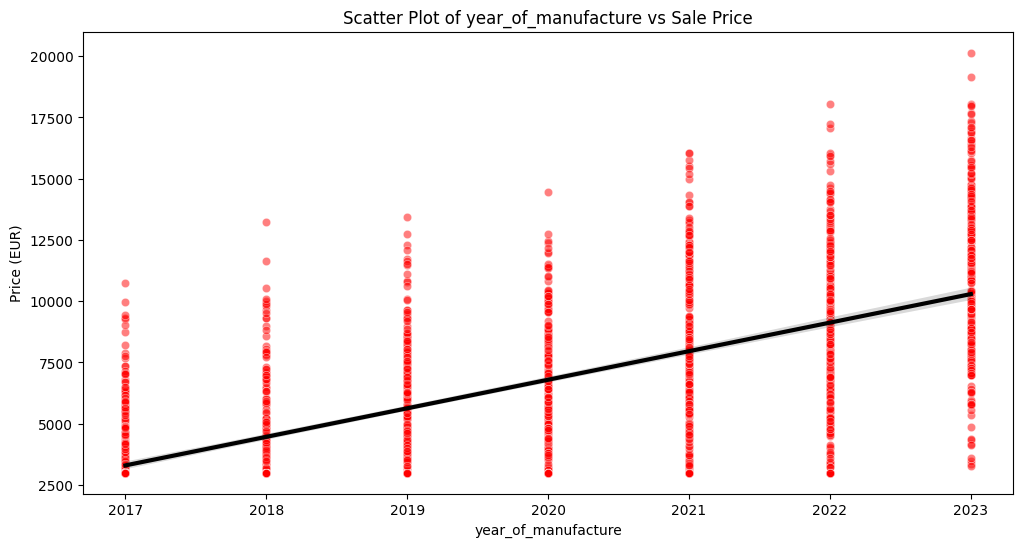

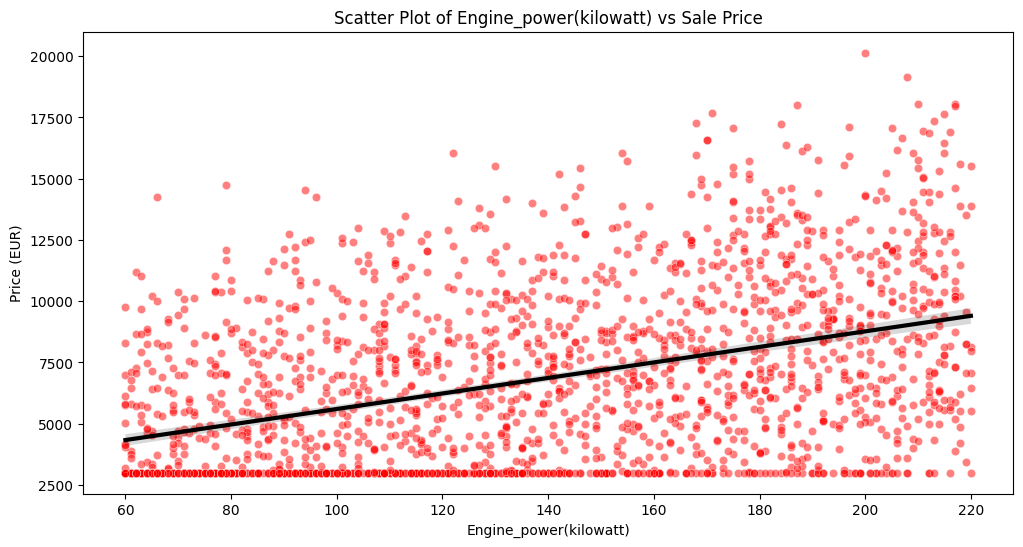

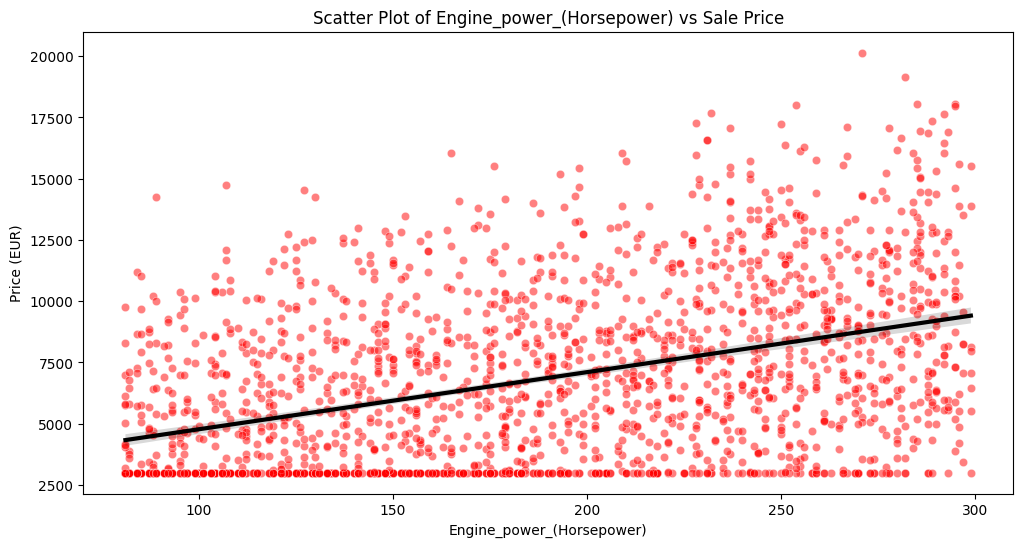

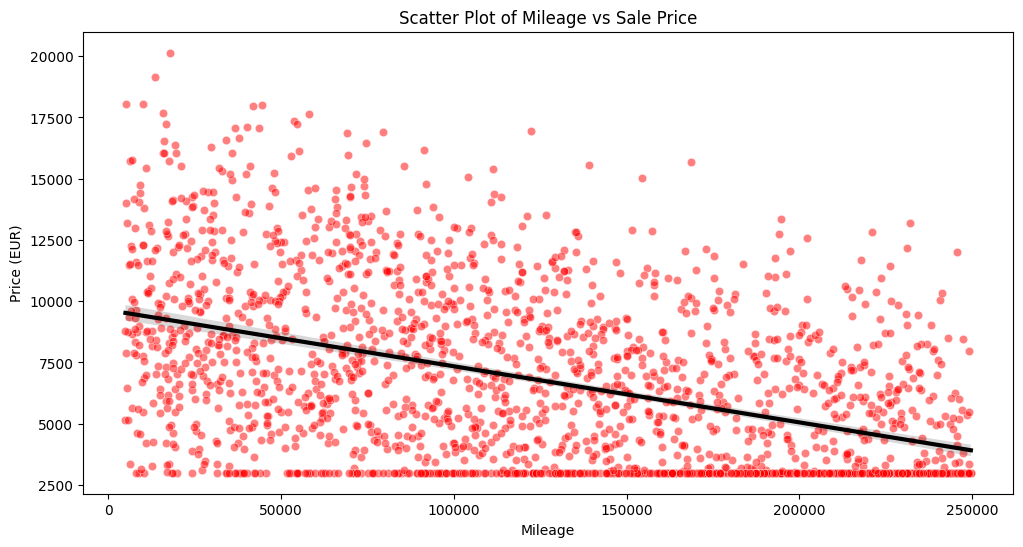

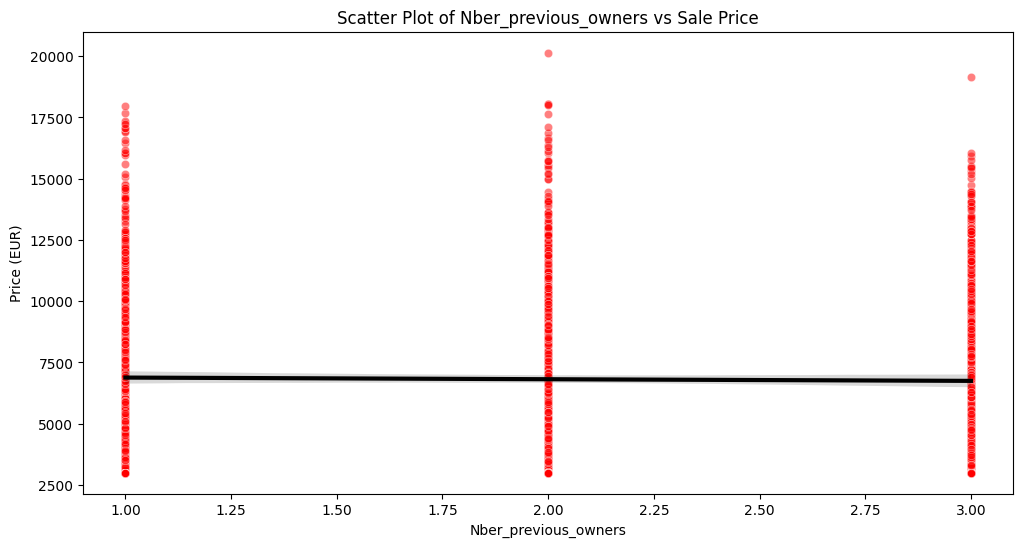

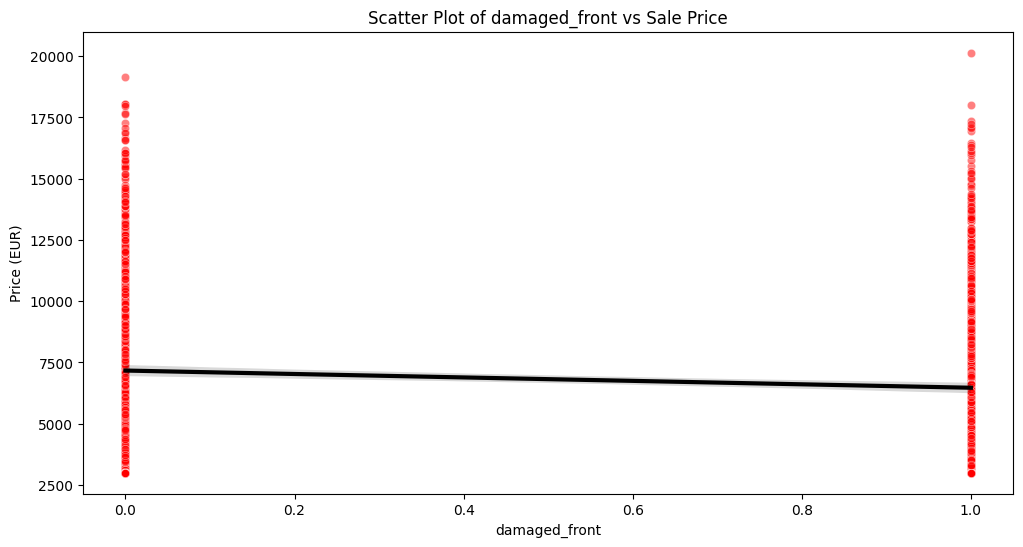

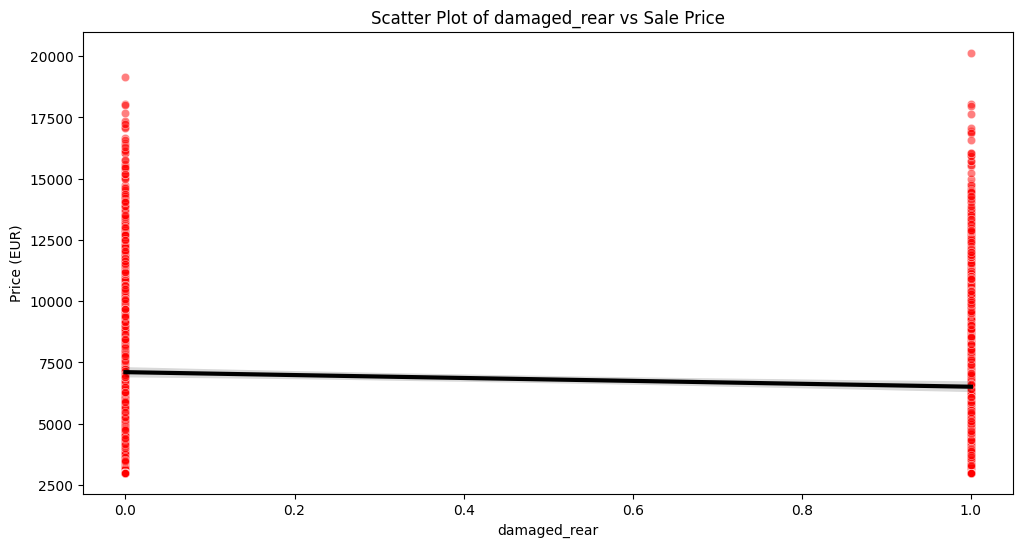

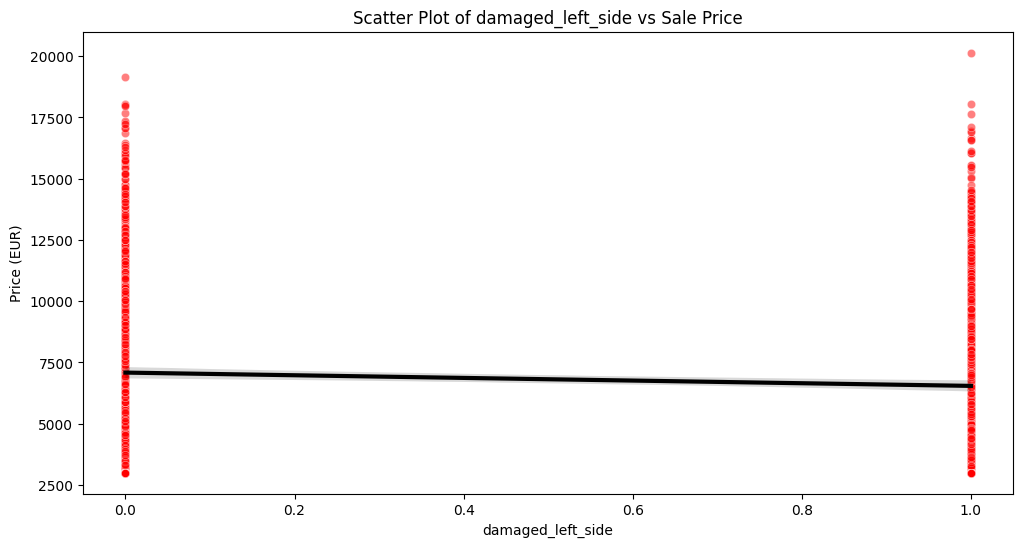

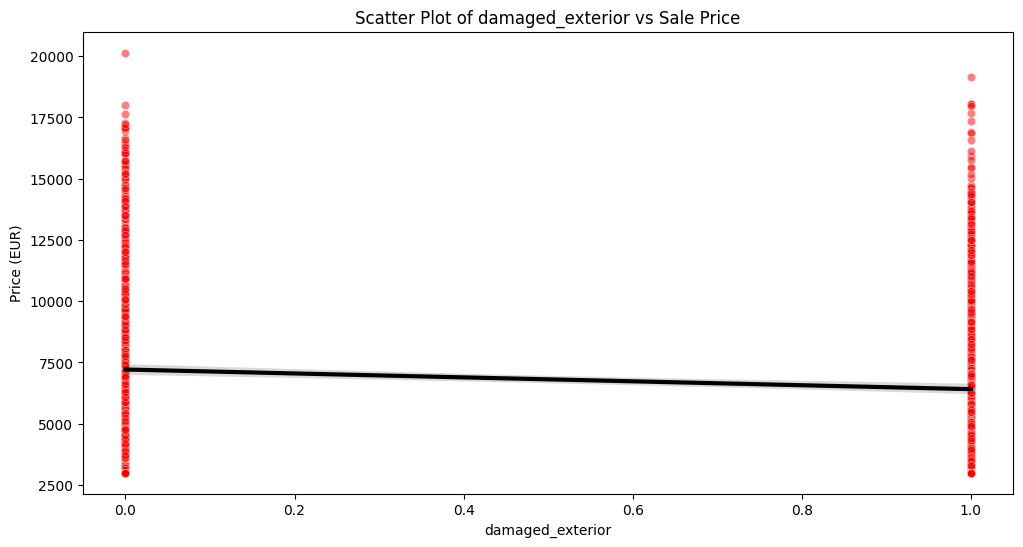

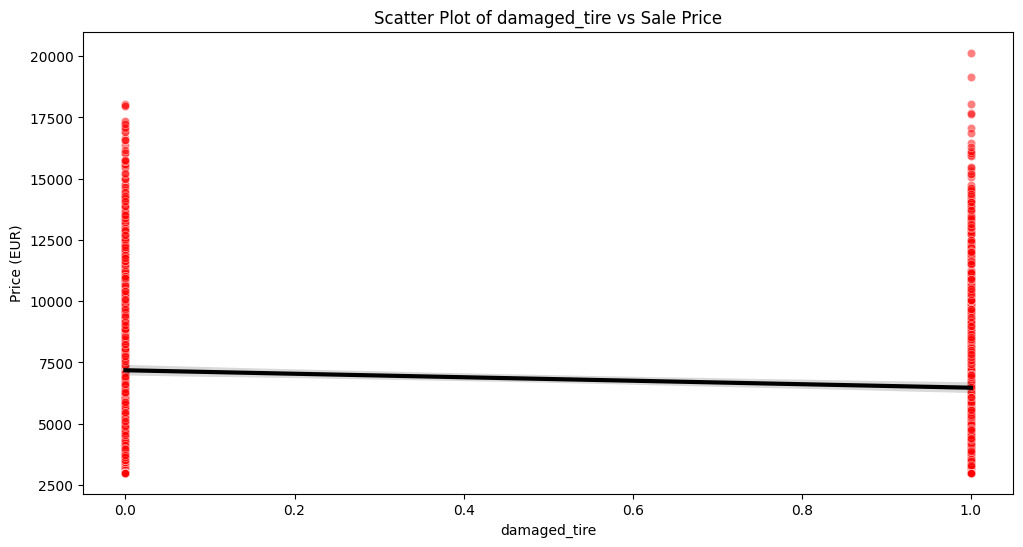

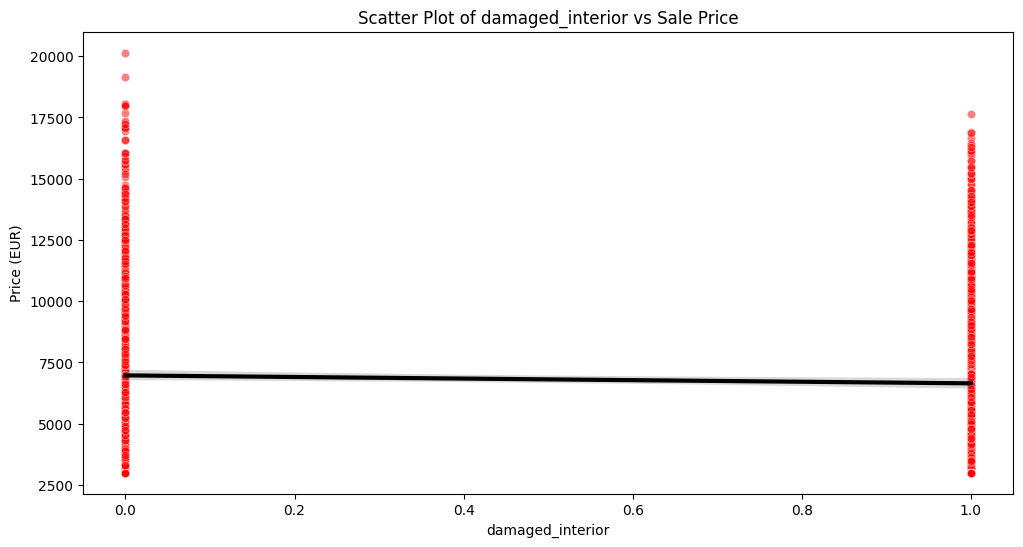

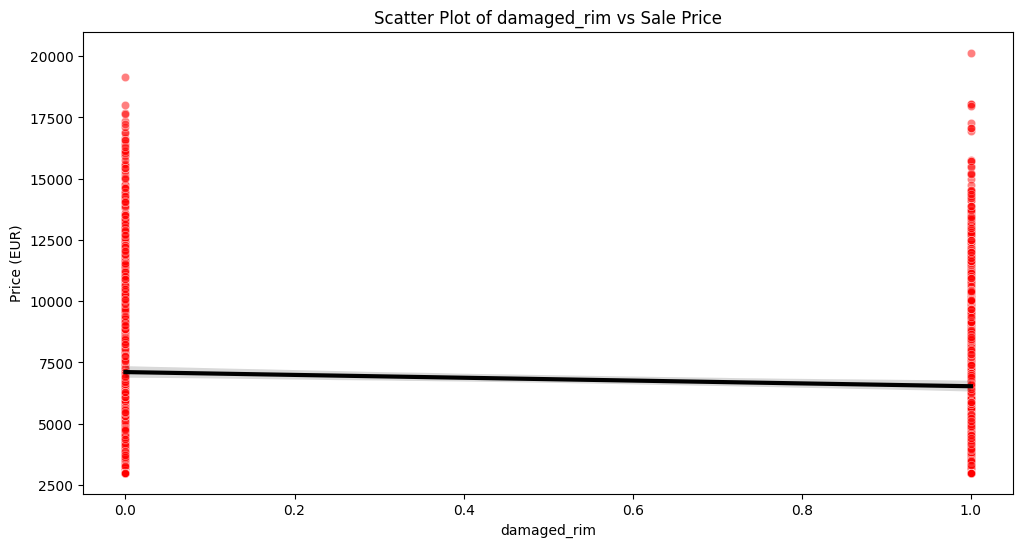

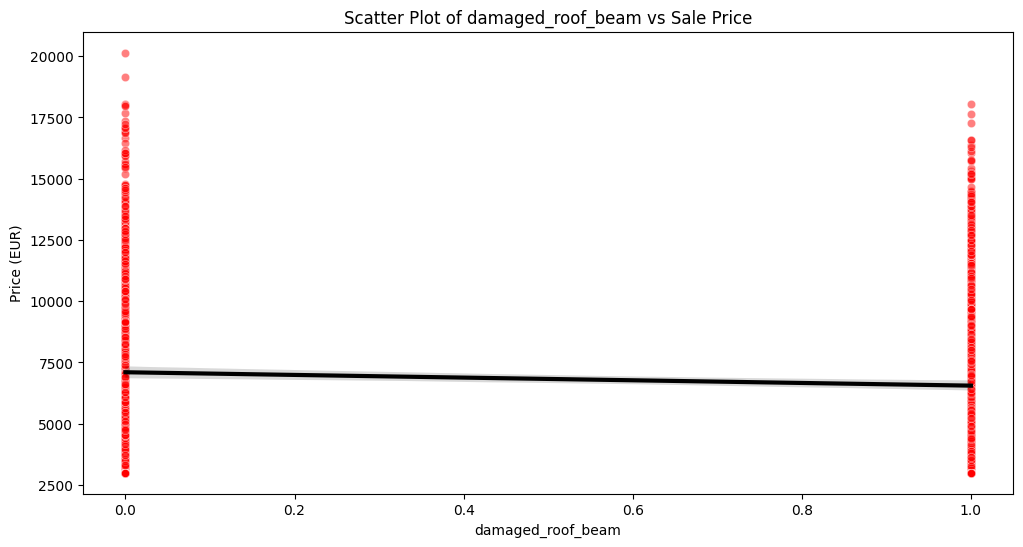

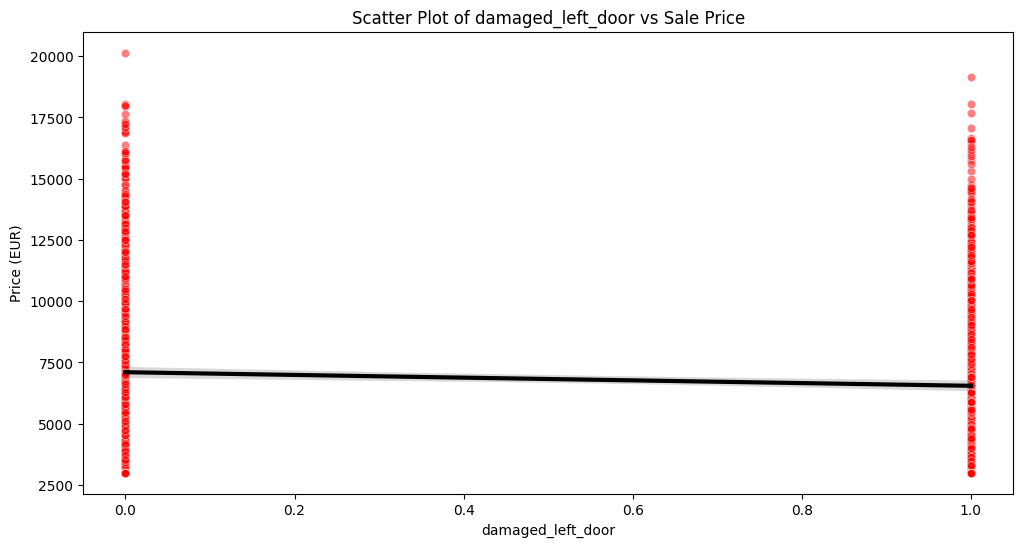

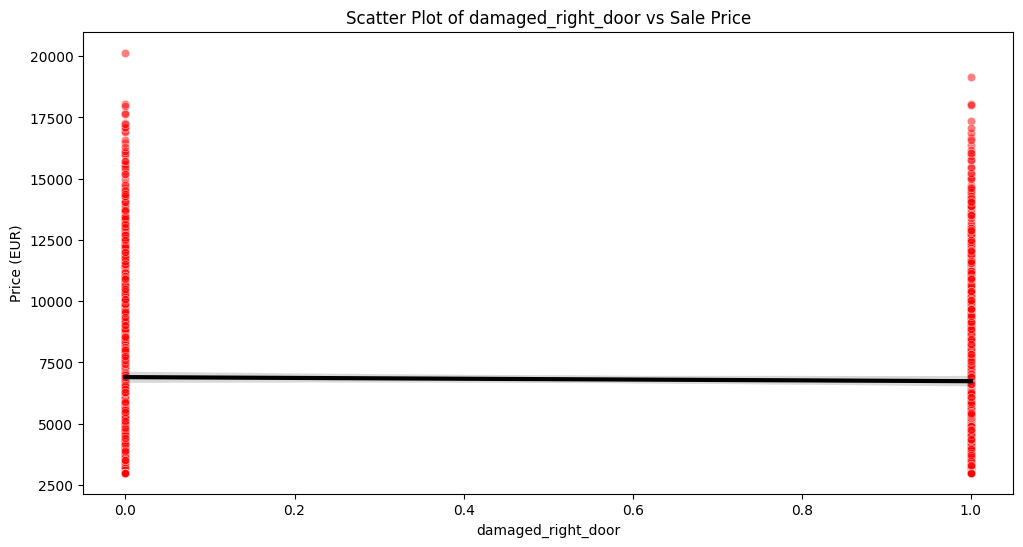

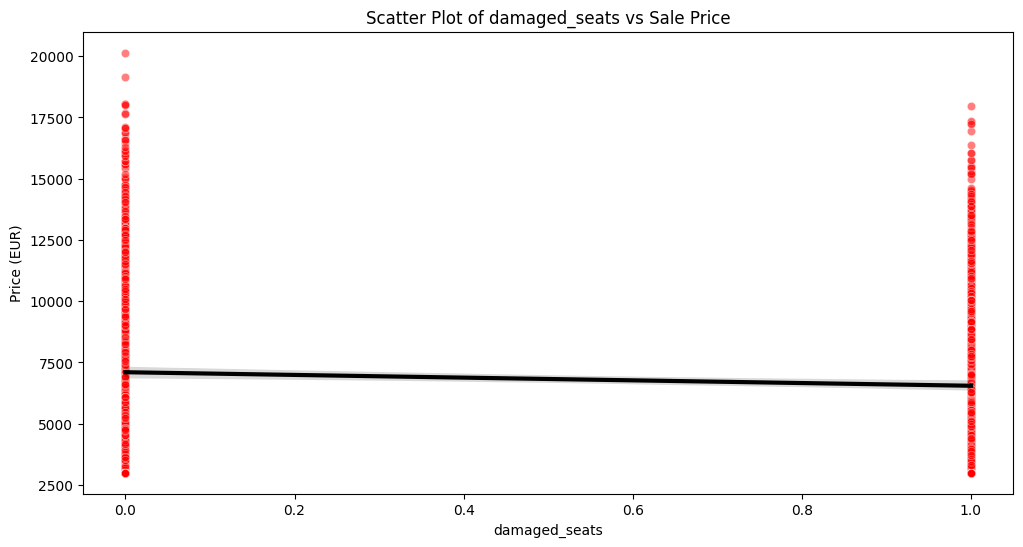

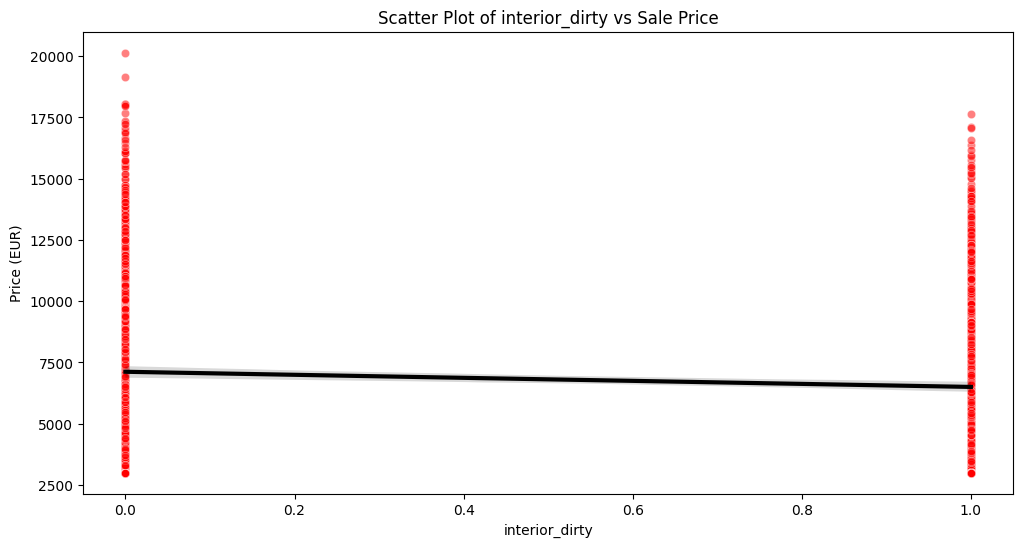

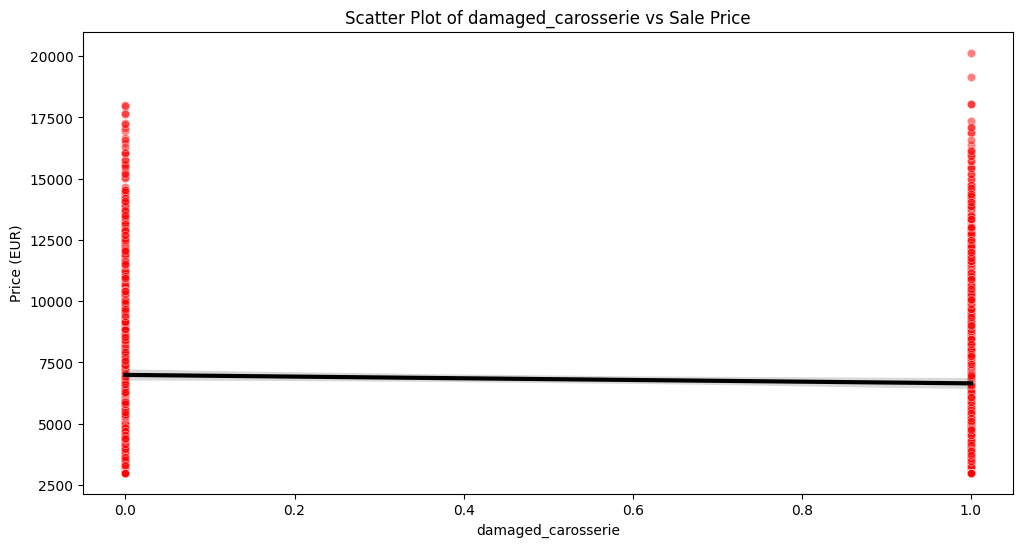

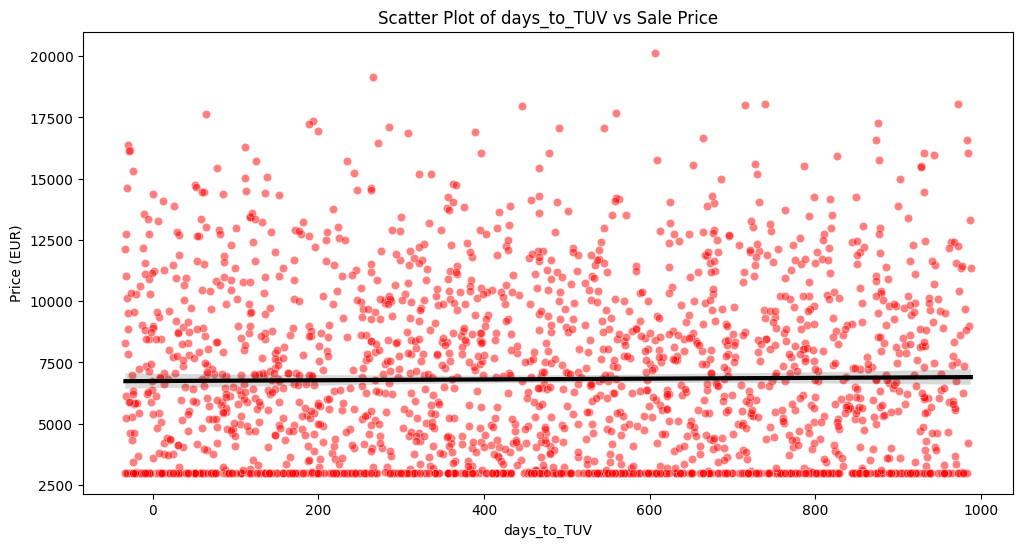

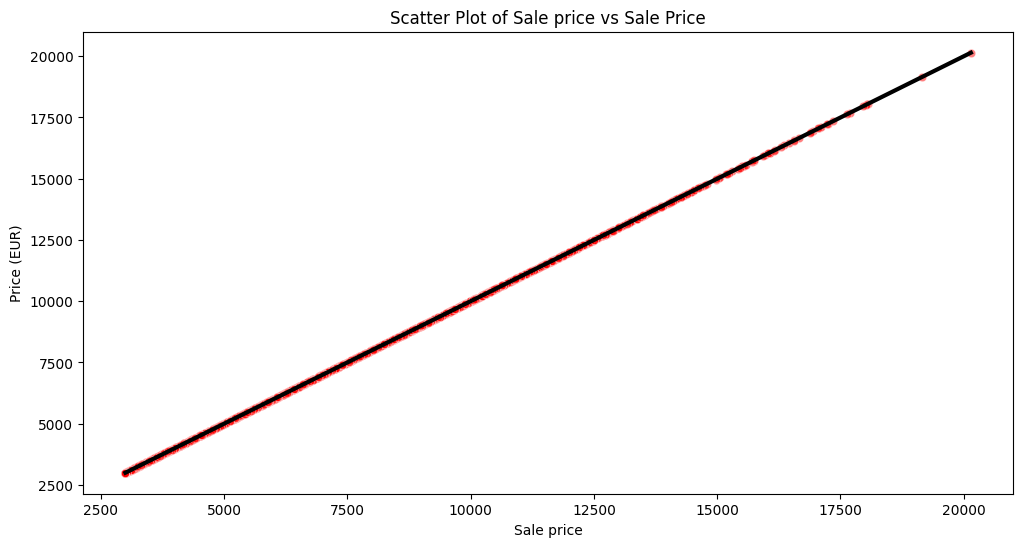

In [7]:
for col in numerical_cols:
    scatter_plot([col])

In [8]:


def box_plot_all_features(features, target='Sale price'):
    """
    Plottet für jede Feature-Spalte einen Boxplot gegen die Zielvariable.
    
    features : Liste der numerischen Feature-Spalten
    target   : Zielvariable auf der y-Achse (z.B. Price)
    """
    for feature in features:
        plt.figure(figsize=(8,6))
        sns.boxplot(x=data[feature], y=data[target])
        plt.title(f'Box Plot of {feature} vs {target}')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.show()

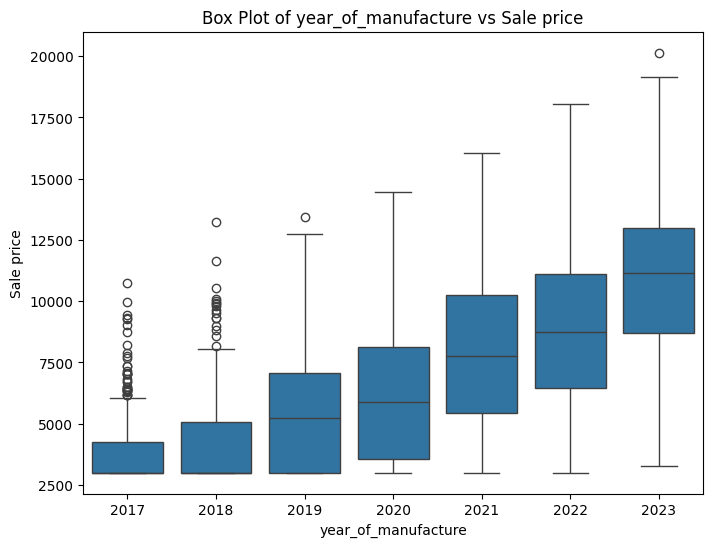

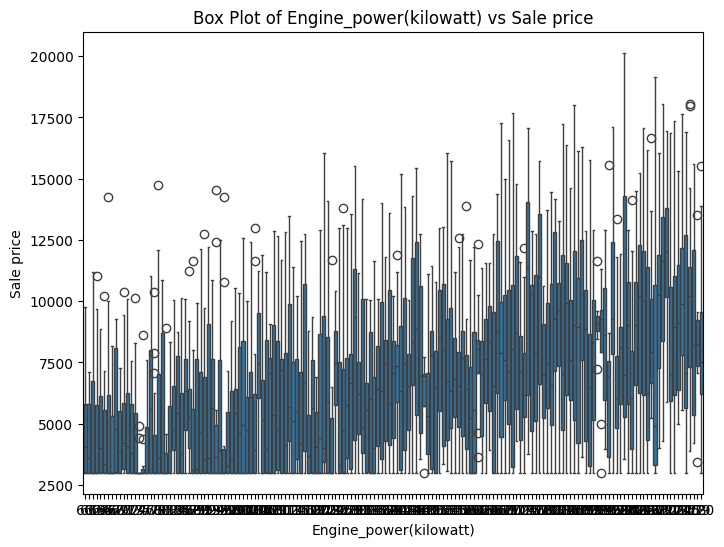

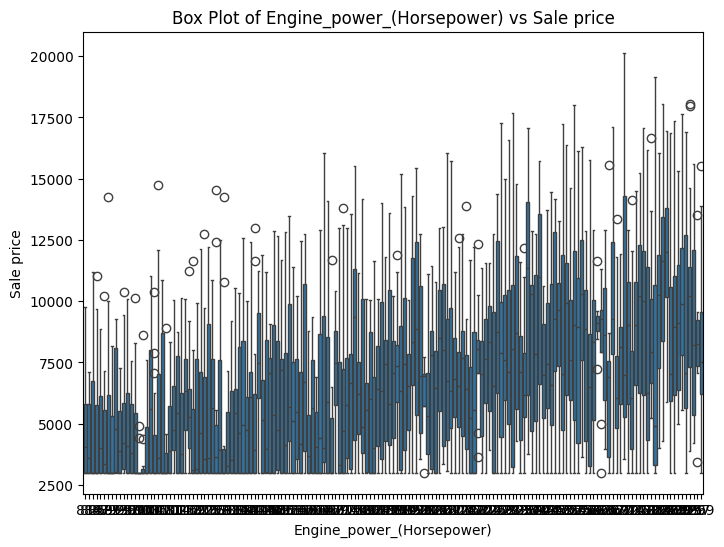

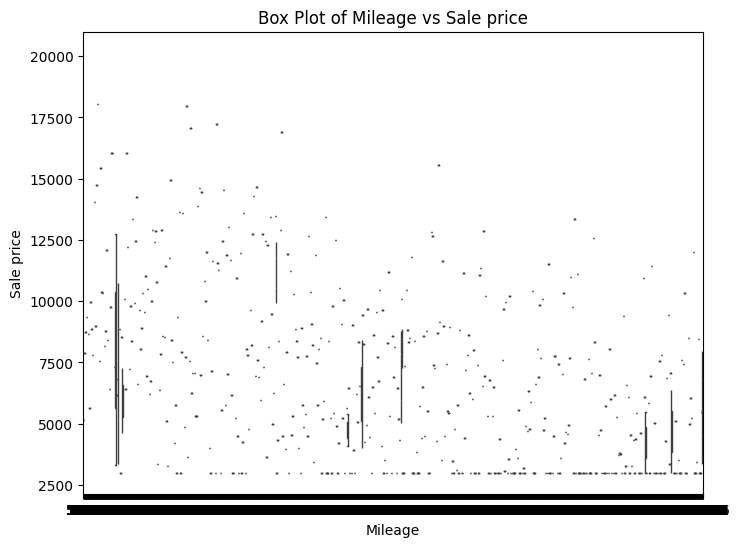

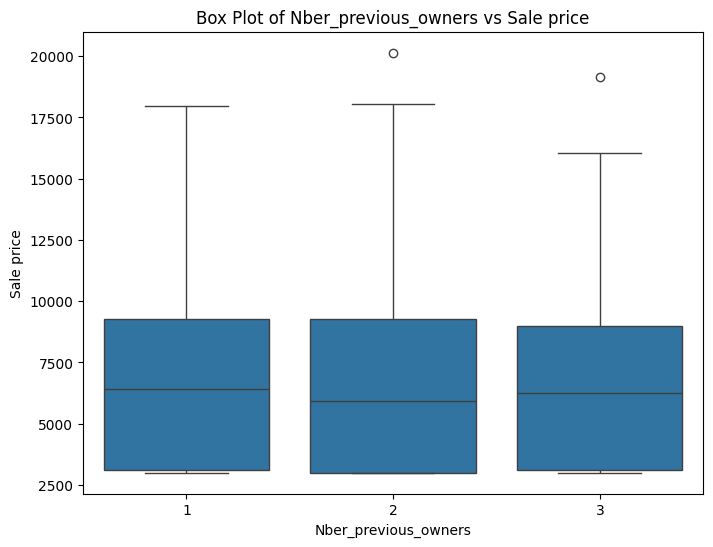

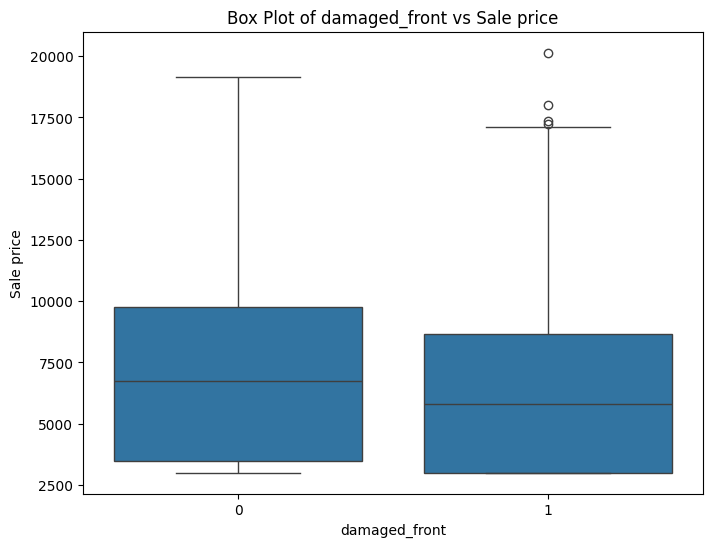

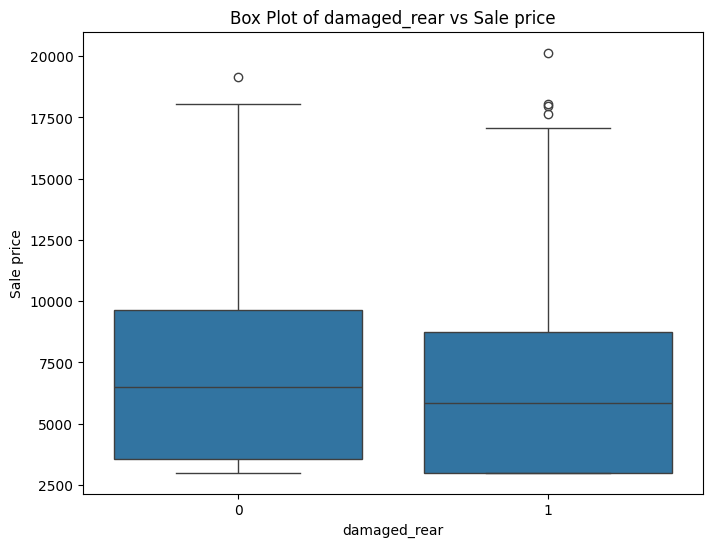

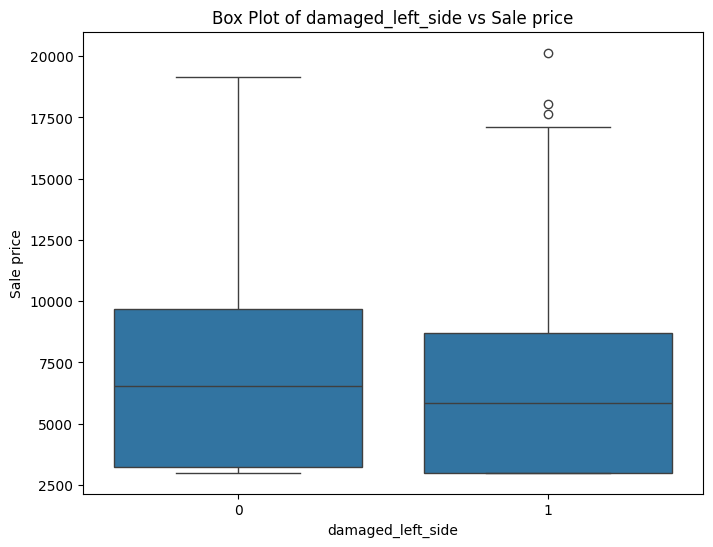

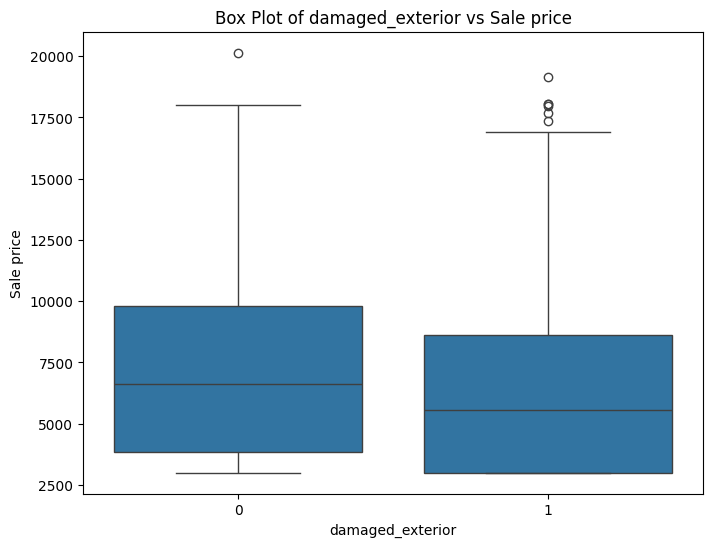

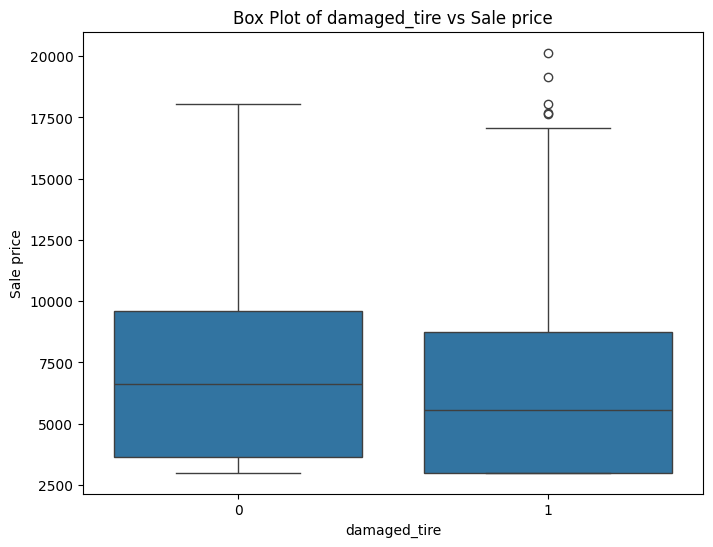

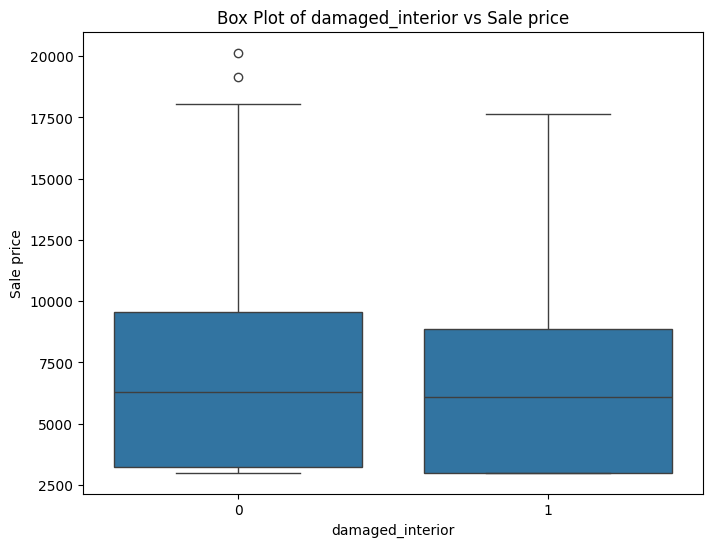

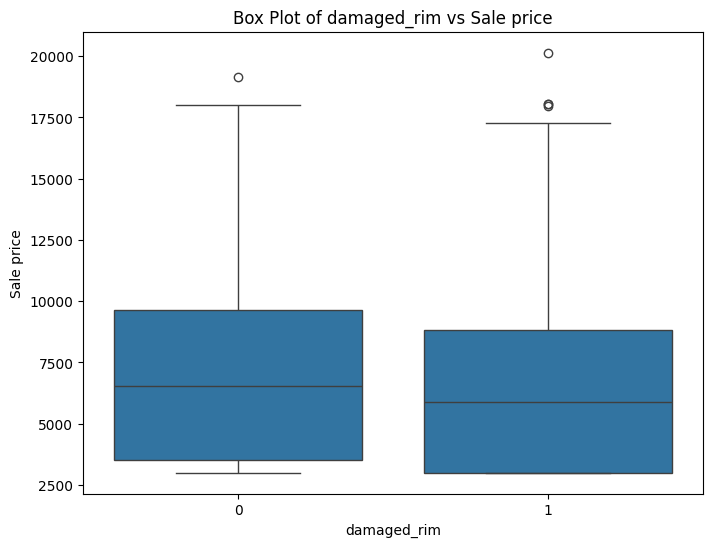

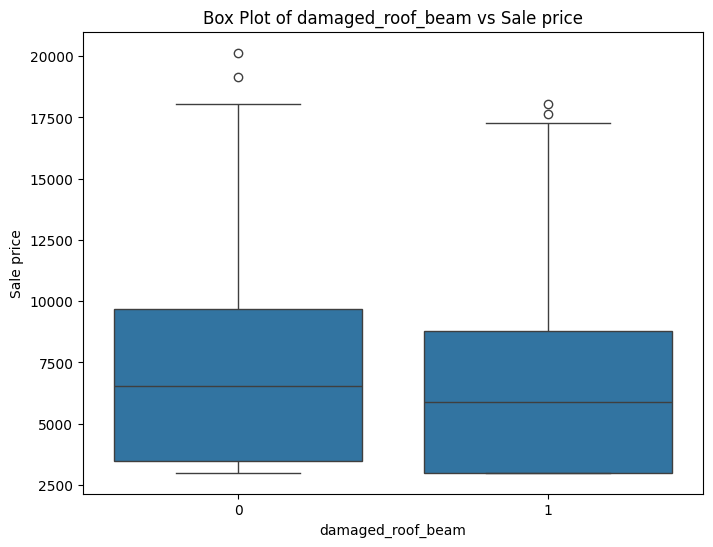

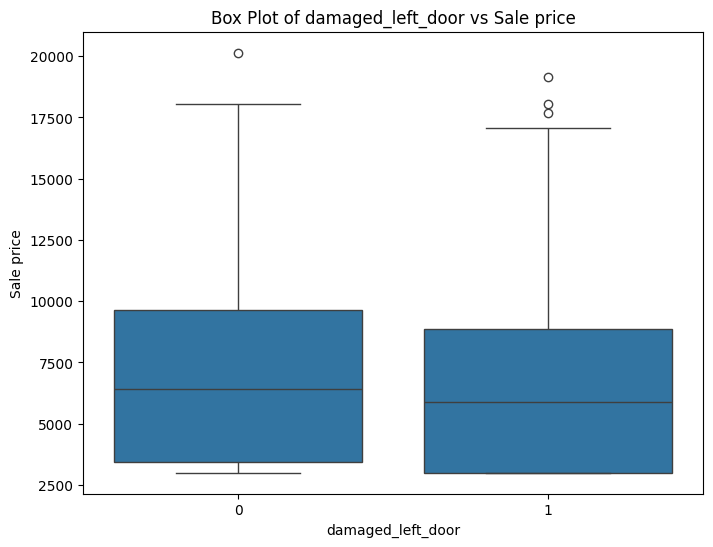

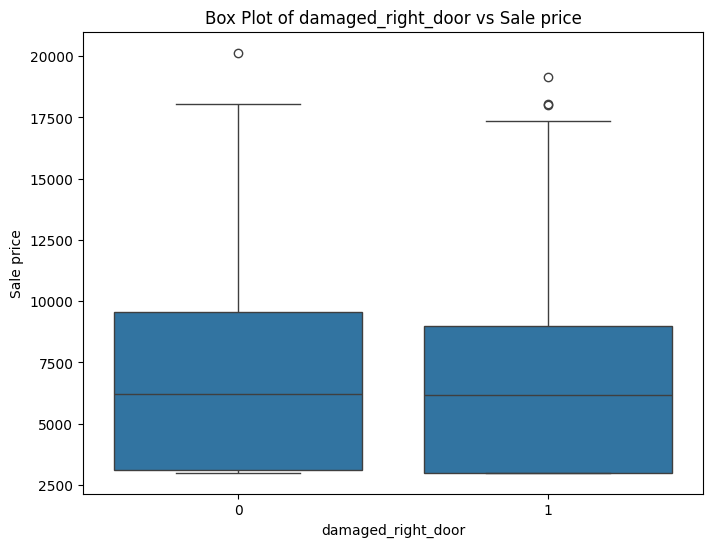

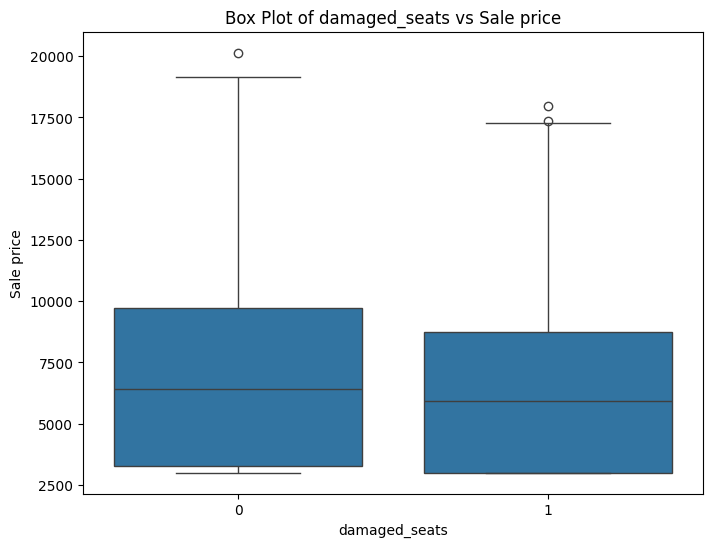

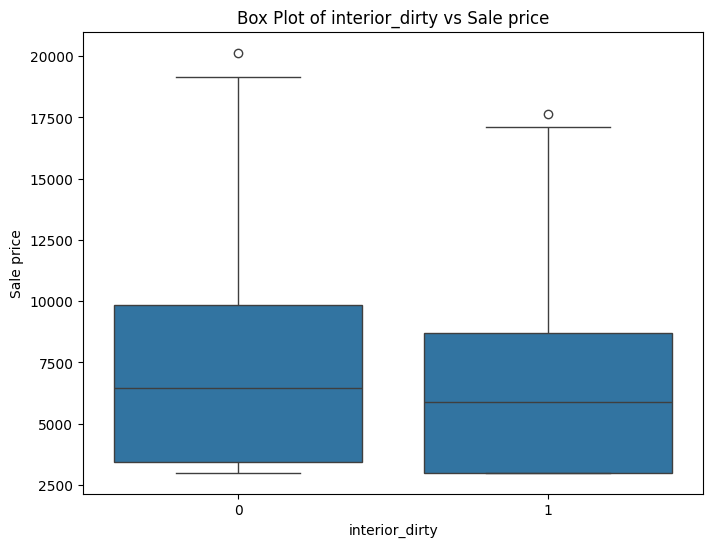

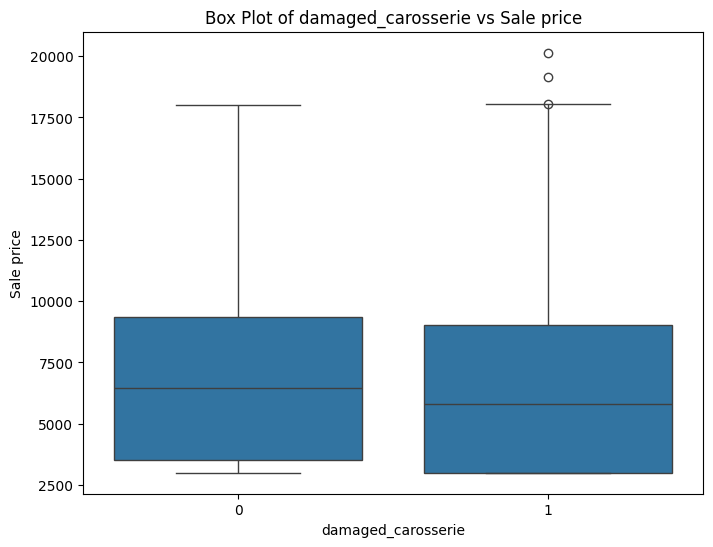

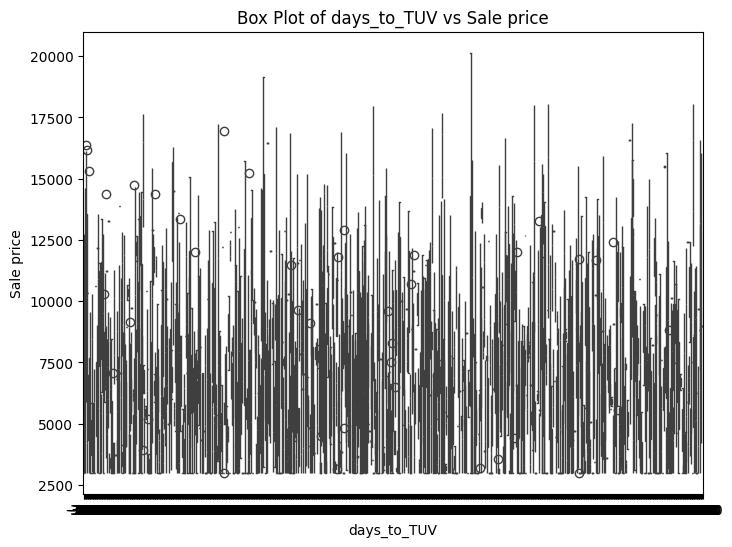

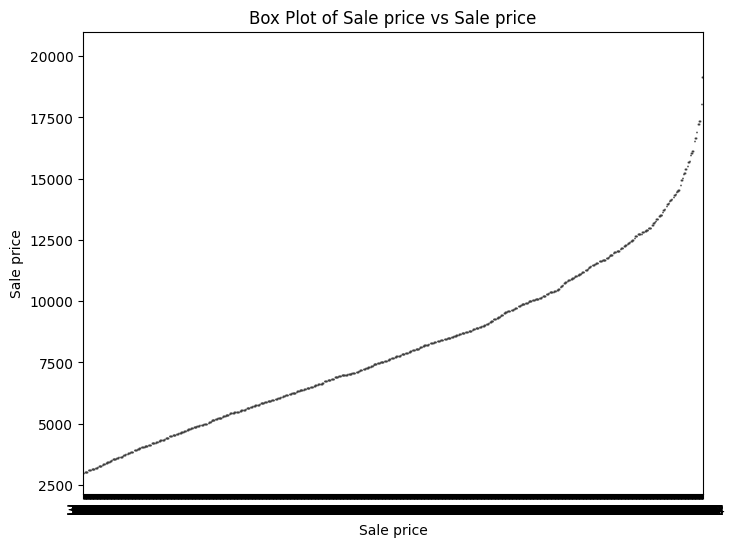

In [9]:
box_plot_all_features(numerical_cols)

In [10]:
def box_plot(x):
    col=x[1]
    
    fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(8,6))

    for i, ax in enumerate(axes.flatten()):
        sns.boxplot(x=data[col], y=data['Sale price'], ax=ax)
        ax.set_title(f'Box Plot of {col} vs Price (EUR)')
        ax.set_xlabel(col)
        ax.set_ylabel('Price (EUR)')

    plt.tight_layout()
    return plt.show()
        
#box_plot(numerical_cols)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def box_plots(features, target='Sale price'):
    """
    features: Liste der numerischen Features
    target  : Zielvariable für y-Achse (z.B. Price)
    """

    n = len(features)
    ncols = 2               # 2 Spalten pro Zeile
    nrows = (n + 1) // 2    # automatisch Zeilen berechnen

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows*5))

    # Flatten axes falls mehr als 1 Zeile
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(features):
        sns.boxplot(x=data[col], y=data[target], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col} vs {target}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)

    # Falls es mehr Subplots gibt als Features, leere Plots entfernen
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [12]:
#box_plots(numerical_cols)

#### Correlation Variables
Analyse relation between variables.

Domain: -1 to 1

. 1 -> perfect positive correlation
. -1 -> perfect negative correlation
. 0 -> no correlation


| r (Korrelationskoeffizient) | Stärke des Zusammenhangs |
| --------------------------- | ------------------------ |
| 0.00 – 0.19                 | sehr schwach             |
| 0.20 – 0.39                 | schwach                  |
| 0.40 – 0.59                 | mittel                   |
| 0.60 – 0.79                 | stark                    |
| 0.80 – 1.0                  | sehr stark               |


In [13]:
# pearson_corr = data[numerical_cols].corr(method='pearson')
# plt.figure(figsize=(100, 90))
# sns.heatmap(pearson_corr,
#              annot=True,
#              vmax=1,
#              vmin=-1,
#              fmt=".2f", 
#              cmap='coolwarm', 
#              center=0,
#             annot_kws={"size": 23} )
# plt.title('Pearson Correlation Heatmap')
# plt.xticks(fontsize=20)  
# plt.yticks(fontsize=20)
# plt.show()

VIF (Variance Inflation Factor) misst, wie stark die Varianz eines Regressionskoeffizienten durch die Korrelation mit anderen unabhängigen Variablen „aufgeblasen“ wird.

Einfach gesagt: VIF sagt dir, wie stark ein Feature redundant mit anderen Features ist.

Hohe VIF-Werte → Multikollinearität → Modell instabil

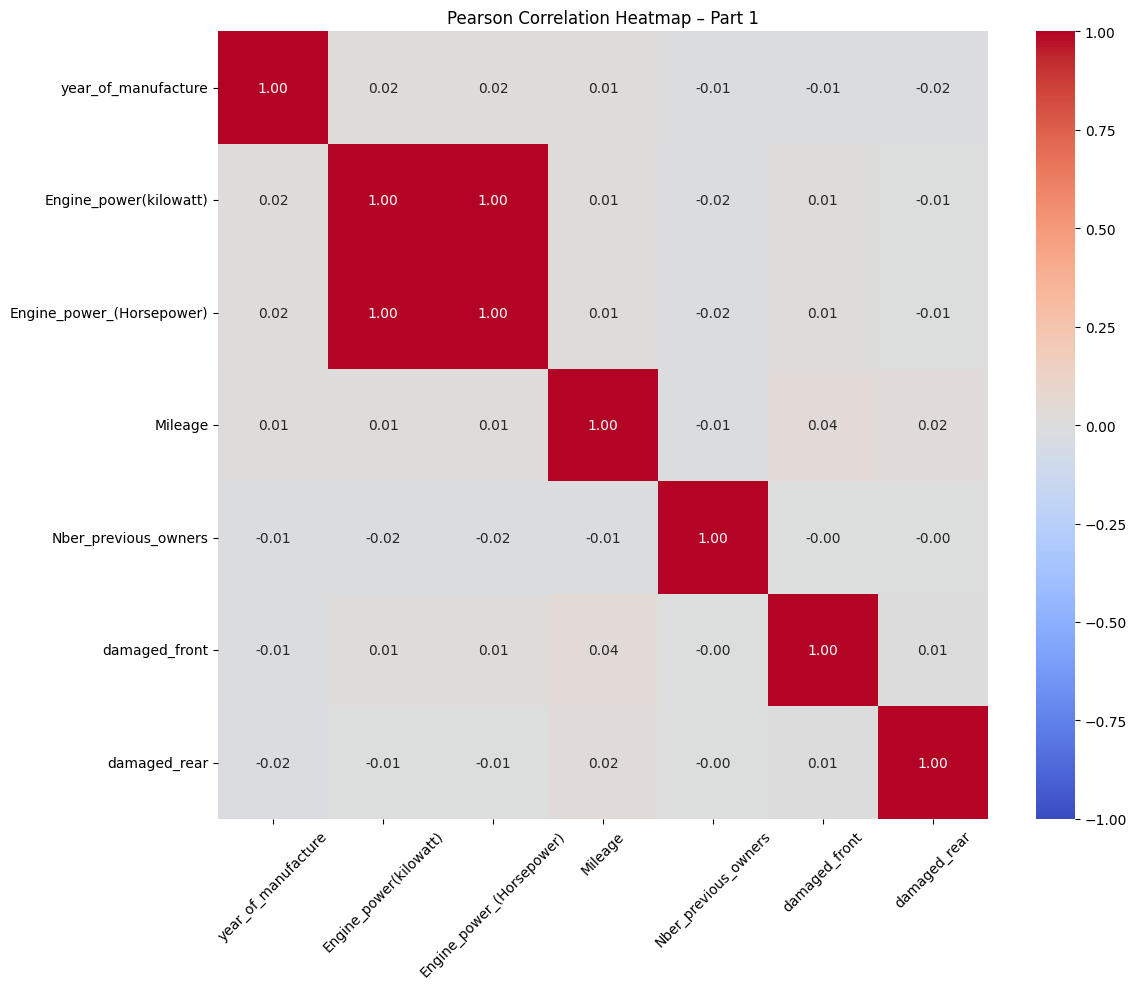

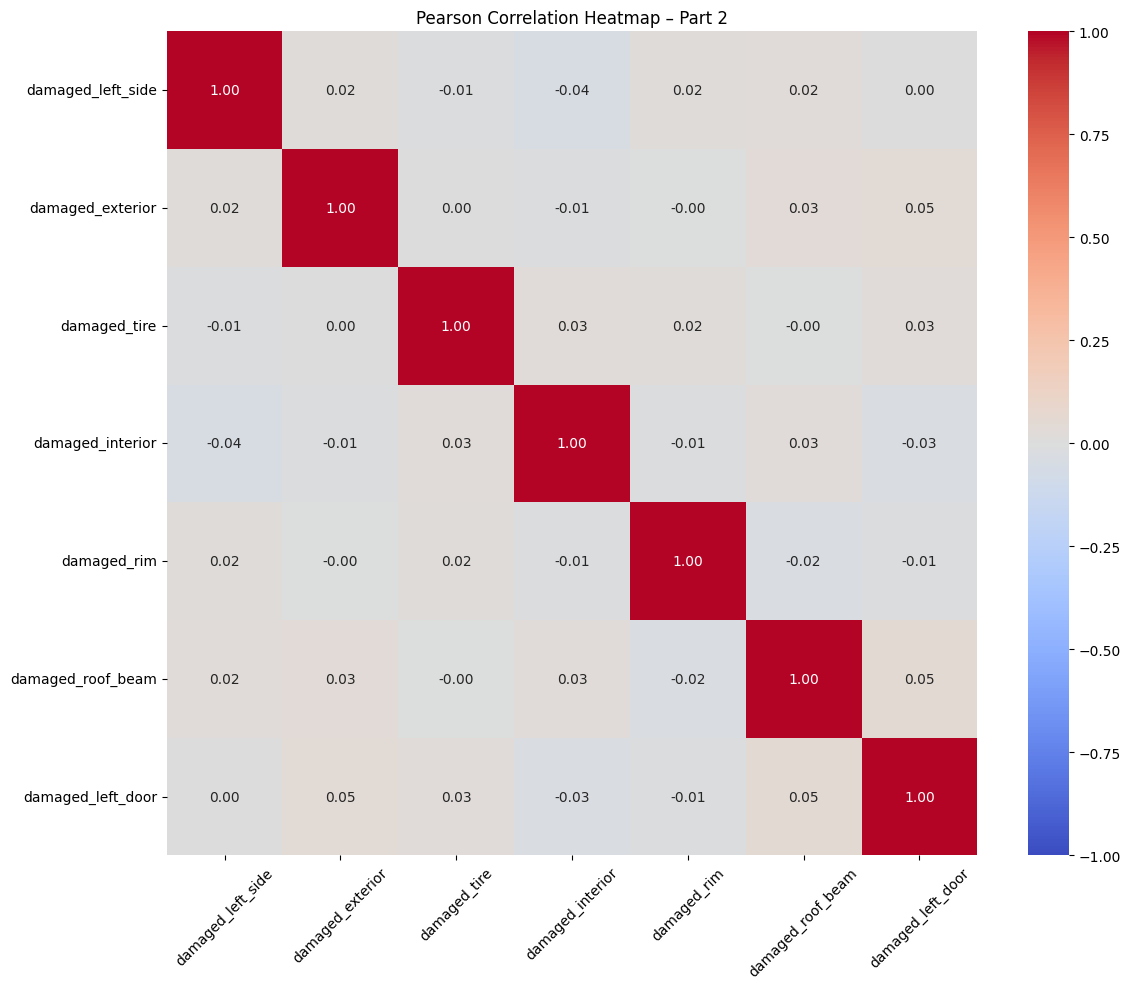

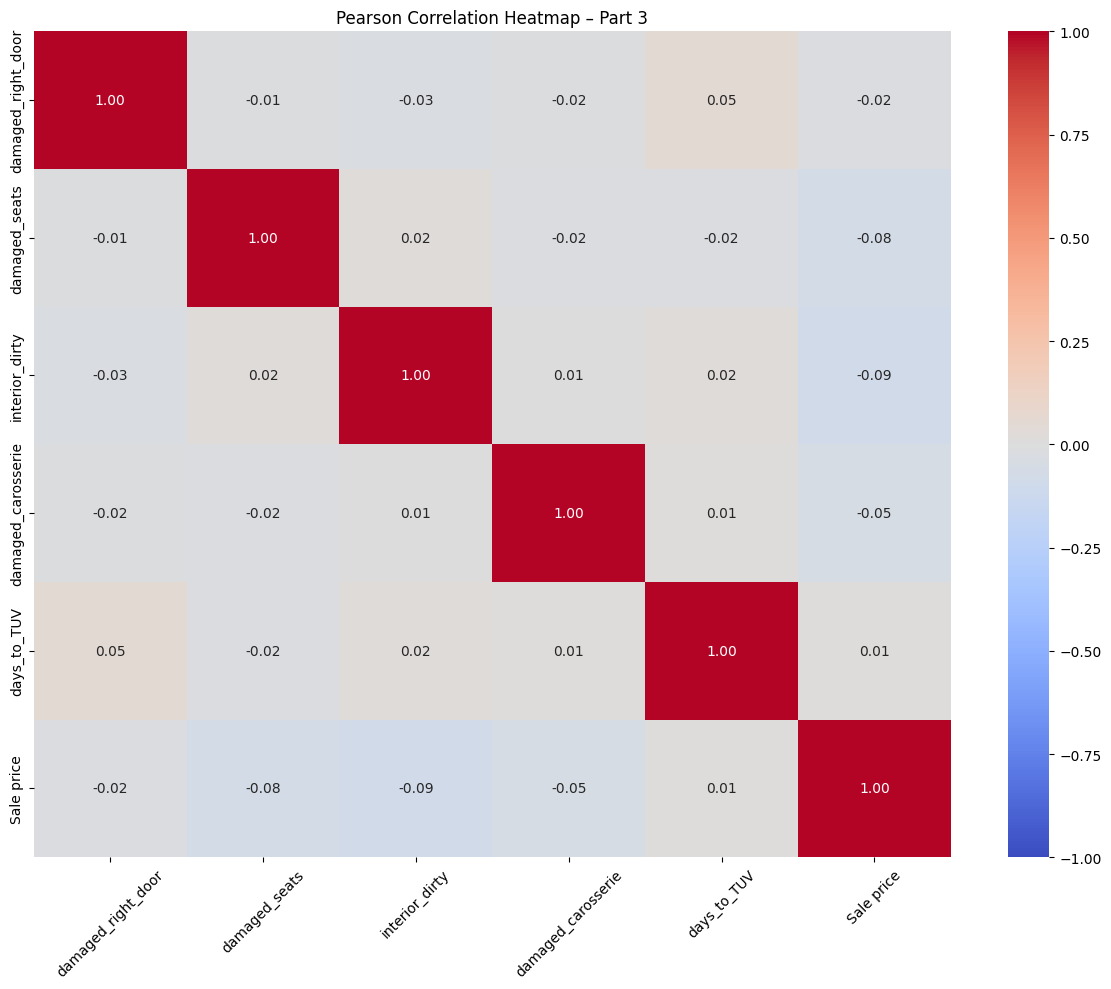

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = data[numerical_cols].corr(method='pearson')

# Anzahl Teile
n_parts = 3

# Spalten in 3 Gruppen splitten
chunks = np.array_split(numerical_cols, n_parts)

for i, cols in enumerate(chunks, 1):

    sub_corr = corr.loc[cols, cols]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        sub_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot_kws={"size": 10}
    )

    plt.title(f"Pearson Correlation Heatmap – Part {i}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [15]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def multi_collinearity_analysis(data):

    # Annahme: numerische Features (ohne Zielvariable)
    numerical_cols = data.select_dtypes(include='number').columns.tolist()
    target = 'Sale price'
    X = data[numerical_cols].drop(target, axis=1).fillna(0)  # unabhängige Variablen

    # 1️. Stark korrelierte Paare erkennen (r > 0.7)
    corr_matrix = X.corr().abs()
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i,j] > 0.7:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))

    print("Stark korrelierte Feature-Paare (r > 0.7):")
    for pair in high_corr_pairs:
        print(f"{pair[0]} ↔ {pair[1]} = {pair[2]:.2f}")

    # VIF berechnen
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    print("\nVariance Inflation Factor (VIF) für jedes Feature:")
    print(vif_data)


In [16]:
multi_collinearity_analysis(data)

Stark korrelierte Feature-Paare (r > 0.7):
Engine_power(kilowatt) ↔ Engine_power_(Horsepower) = 1.00

Variance Inflation Factor (VIF) für jedes Feature:
                      Feature            VIF
0         year_of_manufacture      38.308044
1      Engine_power(kilowatt)  476307.614645
2   Engine_power_(Horsepower)  473992.911464
3                     Mileage       4.096451
4        Nber_previous_owners       7.028057
5               damaged_front       2.031811
6                damaged_rear       1.957222
7           damaged_left_side       2.002774
8            damaged_exterior       1.990065
9                damaged_tire       2.068748
10           damaged_interior       1.945783
11                damaged_rim       2.039379
12          damaged_roof_beam       2.107581
13          damaged_left_door       2.088876
14         damaged_right_door       2.078053
15              damaged_seats       2.080747
16             interior_dirty       1.979709
17         damaged_carosserie       2

In [17]:
print(data.columns.tolist())


['Brand', 'Model', 'year_of_manufacture', 'Engine_power(kilowatt)', 'Engine_power_(Horsepower)', 'Transmission_type', 'Mileage', 'Fueltype', 'Nber_previous_owners', 'Body_style', 'Tire_type', 'Accident_history', 'damaged_front', 'damaged_rear', 'damaged_left_side', 'damaged_exterior', 'damaged_tire', 'damaged_interior', 'damaged_rim', 'damaged_roof_beam', 'damaged_left_door', 'damaged_right_door', 'damaged_seats', 'interior_dirty', 'damaged_carosserie', 'images', 'days_to_TUV', 'Sale price']


In [18]:
# Liste der zu löschenden Spalten
cols_to_drop = ['Engine power (Horsepower)', 'Tank capacity', 'has_foldable_seat_tables','damaged_right_side','CO2 (g/km)','Cubic capacity']

# Nur Spalten löschen, die tatsächlich im DataFrame existieren
cols_to_drop_existing = [col for col in cols_to_drop if col in data.columns]

# Löschen
data = data.drop(columns=cols_to_drop_existing)

# Nur numerische Spalten, die aktuell im DataFrame existieren
numerical_cols = [col for col in numerical_cols if col in data.columns]


In [19]:
multi_collinearity_analysis(data)

Stark korrelierte Feature-Paare (r > 0.7):
Engine_power(kilowatt) ↔ Engine_power_(Horsepower) = 1.00

Variance Inflation Factor (VIF) für jedes Feature:
                      Feature            VIF
0         year_of_manufacture      38.308044
1      Engine_power(kilowatt)  476307.614645
2   Engine_power_(Horsepower)  473992.911464
3                     Mileage       4.096451
4        Nber_previous_owners       7.028057
5               damaged_front       2.031811
6                damaged_rear       1.957222
7           damaged_left_side       2.002774
8            damaged_exterior       1.990065
9                damaged_tire       2.068748
10           damaged_interior       1.945783
11                damaged_rim       2.039379
12          damaged_roof_beam       2.107581
13          damaged_left_door       2.088876
14         damaged_right_door       2.078053
15              damaged_seats       2.080747
16             interior_dirty       1.979709
17         damaged_carosserie       2

In [20]:
numerical_cols.remove('Engine_power_(Horsepower)')

In [21]:
print(data.columns.tolist())



['Brand', 'Model', 'year_of_manufacture', 'Engine_power(kilowatt)', 'Engine_power_(Horsepower)', 'Transmission_type', 'Mileage', 'Fueltype', 'Nber_previous_owners', 'Body_style', 'Tire_type', 'Accident_history', 'damaged_front', 'damaged_rear', 'damaged_left_side', 'damaged_exterior', 'damaged_tire', 'damaged_interior', 'damaged_rim', 'damaged_roof_beam', 'damaged_left_door', 'damaged_right_door', 'damaged_seats', 'interior_dirty', 'damaged_carosserie', 'images', 'days_to_TUV', 'Sale price']


In [22]:
%store data
%store numerical_cols

Stored 'data' (DataFrame)
Stored 'numerical_cols' (list)
